In [1]:
import numpy as np

def sigmoid(x):
    """Sigmoid activation function."""
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    """Derivative of the sigmoid function."""
    return x * (1 - x)

class NeuralNetwork:
    def __init__(self, input_size, hidden_size, output_size):
        """Initializes the neural network with random weights."""
        self.weights1 = np.random.randn(input_size, hidden_size)  # Weights between input and hidden layer
        self.bias1 = np.random.randn(1, hidden_size)       # Biases for the hidden layer
        self.weights2 = np.random.randn(hidden_size, output_size) # Weights between hidden and output layer
        self.bias2 = np.random.randn(1, output_size)      # Biases for the output layer

    def forward(self, X):
        """Performs forward propagation."""
        self.hidden_layer_output = sigmoid(np.dot(X, self.weights1) + self.bias1)
        self.output = sigmoid(np.dot(self.hidden_layer_output, self.weights2) + self.bias2)
        return self.output

    def backward(self, X, y, learning_rate):
        """Performs backpropagation and updates weights."""

        # Output layer
        error_output = y - self.output
        delta_output = error_output * sigmoid_derivative(self.output)
        
        # Hidden layer
        error_hidden = delta_output.dot(self.weights2.T)
        delta_hidden = error_hidden * sigmoid_derivative(self.hidden_layer_output)

        # Update weights and biases
        self.weights2 += self.hidden_layer_output.T.dot(delta_output) * learning_rate
        self.bias2 += np.sum(delta_output, axis=0, keepdims=True) * learning_rate
        self.weights1 += X.T.dot(delta_hidden) * learning_rate
        self.bias1 += np.sum(delta_hidden, axis=0, keepdims=True) * learning_rate



    def train(self, X, y, epochs=10000, learning_rate=0.1):
        """Trains the neural network."""
        for epoch in range(epochs):
            output = self.forward(X)
            self.backward(X, y, learning_rate)
            if epoch % 100 == 0:  # Print loss every 1000 epochs (optional)
                loss = np.mean(np.square(y - output)) # Example loss function (MSE)
                print(f"Epoch: {epoch}, Loss: {loss}")
                self.prune()

    def prune(self, threshold = 0.5):
        self.weights1[abs(self.weights1) < threshold] = -0.5
        self.weights2[abs(self.weights2) < threshold] = -0.5
        self.weights1[abs(self.weights1) > threshold] = 0.5
        self.weights2[abs(self.weights2) > threshold] = 0.5
        
    def predict(self, X):
        """Makes predictions."""
        return self.forward(X)


# Example usage (XOR problem):
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])  # Input data
y = np.array([[0], [1], [1], [0]])  # Target output

nn = NeuralNetwork(input_size=2, hidden_size=1, output_size=1) # 2 inputs, 4 hidden nodes, 1 output
nn.train(X, y, epochs=1000, learning_rate=3.5) # Train the model

# Make predictions:
predictions = nn.predict(X)
print("Predictions:")
print(predictions)

print(nn.weights1, nn.weights2)

Epoch: 0, Loss: 0.2993825880070355
Epoch: 100, Loss: 0.19797508481702994
Epoch: 200, Loss: 0.2500306918520978
Epoch: 300, Loss: 0.24997686747836004
Epoch: 400, Loss: 0.25003091333997784
Epoch: 500, Loss: 0.24997720552686553
Epoch: 600, Loss: 0.25003070788254533
Epoch: 700, Loss: 0.24997753662661076
Epoch: 800, Loss: 0.25003050293104745
Epoch: 900, Loss: 0.2499778609263033
Predictions:
[[0.49973658]
 [0.4999682 ]
 [0.4999682 ]
 [0.50032084]]
[[0.42568307]
 [0.42568307]] [[0.441042]]


# Dependency Map of Fundamental AI Concepts

## Foundational Principles:

Mathematical Foundations: Linear algebra, calculus, probability theory, optimization.
Computational Principles: Gradient-based optimization, backpropagation, approximation theory.
Domain-Specific Principles: Signal processing (convolution/pooling), decision theory (RL), linguistic semantics (token embedding).

## Core Concepts & Dependencies

### Neuron
Dependencies: None (atomic unit).
Founding Principles: Biological inspiration (simplified), linear/nonlinear transformations, activation functions (e.g., ReLU, sigmoid).

### Neural Network
Dependencies: Neuron, backpropagation, loss functions (e.g., cross-entropy, MSE), optimization algorithms (e.g., SGD, Adam).
Founding Principles: Universal approximation theorem, gradient descent, computational graphs.

### Feed Forward Network (FFN)
Dependencies: Neural network, directed acyclic graph structure.
Founding Principles: Layer-wise feature transformation, non-convex optimization.

Convolution
Dependencies: Neural network, linear algebra, signal processing.
Founding Principles: Local connectivity, translation invariance, kernel methods.

### Pooling
Dependencies: Convolutional neural network (CNN), downsampling operations.
Founding Principles: Dimensionality reduction, feature invariance (scale/rotation).

### Token Embedding
Dependencies: Data preprocessing, neural network (for learning representations).
Founding Principles: Vector space models, distributional semantics, manifold hypothesis.

### Attention
Dependencies: Neural network (specifically transformers), token embedding.
Founding Principles: Resource allocation, context-aware weighting, query-key-value mechanisms.

### Mixture-of-Experts (MoE)
Dependencies: Neural network, ensemble methods, gating mechanisms.
Founding Principles: Conditional computation, sparsity, parallelizable training.

### Reinforcement Learning (RL)
Dependencies: Markov decision processes (MDP), dynamic programming, Monte Carlo methods.
Founding Principles: Bellman equations, exploration-exploitation trade-off, policy gradient theorems.

### Group Relative Policy Automation (Proposed Clarification: Likely refers to Policy Optimization in Multi-Agent RL or Hierarchical RL)
Dependencies: Reinforcement learning, game theory, optimization.
Founding Principles: Nash equilibrium, decentralized control, credit assignment.

## Missing Essential Concepts (Added)
Backpropagation: Critical for training neural networks; depends on chain rule, automatic differentiation.
Activation Functions: Enable nonlinearity in neurons (e.g., ReLU, tanh, softmax).
Loss Functions: Quantify model error (e.g., cross-entropy, MSE); depends on task type (classification/regression).
Transformers: Architecture leveraging attention; depends on token embedding, positional encoding.
Optimization Algorithms: e.g., SGD, Adam; depends on convex/non-convex optimization theory.

## Dependency Graph Structure

Mathematical Foundations → Neuron → Neural Network → Feed Forward Network  
                                  ↓  
                          Convolution → Pooling → CNN  
                                  ↓  
                          Token Embedding → Attention → Transformer → Mixture-of-Experts  
                                  ↓  
                          Reinforcement Learning → Group Relative Policy Automation  

### Mapping to Founding Principles
Neural Networks: Universal approximation theorem, gradient-based optimization.
CNNs: Signal processing (convolution/pooling), invariance principles.
Attention/Transformers: Context modeling, parallelization.
RL: Markov decision processes, Bellman equations.
MoE: Ensemble learning, conditional computation.
This map adheres to scientific rigor, avoiding speculation. Missing concepts (e.g., backpropagation, activation functions) are explicitly added as essential dependencies. The graph is hierarchical, with foundational principles at the base and complex architectures/methods built atop.

In [ ]:
Level 0: Principles
├── Biological Inspiration
├── Statistical Learning Theory
├── Computational Theory
└── Information Theory

Level 1: Mathematical Foundations
├── Linear Algebra (all operations)
├── Calculus (optimization)
├── Probability (learning)
└── Graph Theory (architectures)

Level 2: Core Components
├── Neuron (activation, summation)
├── Loss Functions (objective formulation)
├── Gradient Descent (optimization core)
└── Distributed Representations

Level 3: Basic Systems
├── Feed Forward Network
├── Backpropagation
├── Neural Network
└── Token Embedding

Level 4: Specialized Mechanisms
├── Convolution → Pooling
├── Attention
├── Recurrent Connections
└── Markov Decision Processes (for RL)

Level 5: Advanced Architectures
├── Transformers
├── Mixture-of-Experts
└── Reinforcement Learning Systems

Level 6: Composite Systems
└── Group Relative Policy Automation

## Evaluation of AI Concepts Against "The Bitter Lesson" Principles

### **Core Thesis of "The Bitter Lesson" (Rich Sutton, 2019)**
1. **General methods** that leverage computation scale most effectively
2. **Search and learning** outperform human-designed knowledge
3. **Scale** (computation, data) ultimately dominates over specialized design
4. **Historical pattern**: Methods exploiting computation beat human-crafted solutions

---

## **Analysis of Level 2+ Concepts Against Bitter Lesson Principles**

### **Level 2: Core Components**
**Neuron (activation function)**
- **Bitter Lesson Alignment**: ✅ High - Universal computational unit
- **Specificity**: Low - General differentiable nonlinearity
- **Scales with**: Computation, parallelization
- **Common Element**: **Differentiable parameterization** (enables scaling via gradient methods)

**Loss Functions**
- **Bitter Lesson Alignment**: ✅ High - General objective formulation
- **Specificity**: Low - Domain-agnostic (MSE, cross-entropy apply broadly)
- **Scales with**: Data, optimization
- **Common Element**: **Scalar optimization target** (unified learning signal)

**Gradient Descent**
- **Bitter Lesson Alignment**: ✅ High - General optimization framework
- **Specificity**: None - Applies to any differentiable system
- **Scales with**: Computation, parallelization
- **Common Element**: **Iterative improvement via gradients** (foundation for scaling)

### **Level 3: Basic Systems**
**Feed Forward Network**
- **Bitter Lesson Alignment**: ✅ High - Universal function approximator
- **Specificity**: None - General architecture
- **Scales with**: Parameters, data, compute
- **Common Element**: **Composition of differentiable transformations**

**Backpropagation**
- **Bitter Lesson Alignment**: ✅ High - General algorithm for gradient computation
- **Specificity**: None - Applies to any differentiable graph
- **Scales with**: Network depth/width
- **Common Element**: **Chain rule implementation** (enables deep scaling)

**Neural Network**
- **Bitter Lesson Alignment**: ✅ High - General learning framework
- **Specificity**: None - Architecture-agnostic concept
- **Scales with**: All resources (compute, data, parameters)
- **Common Element**: **Parameterized computation graphs**

**Token Embedding**
- **Bitter Lesson Alignment**: ✅ High - Learned representations beat handcrafted features
- **Specificity**: Medium - Originally for discrete symbols, now general
- **Scales with**: Vocabulary size, embedding dimensions
- **Common Element**: **Distributed continuous representations** (learned, not designed)

### **Level 4: Specialized Mechanisms**
**Convolution**
- **Bitter Lesson Alignment**: ⚠️ Mixed - Domain-specific (spatial locality)
- **Specificity**: High - Assumes grid/topological structure
- **Scales with**: Local receptive fields, depth
- **Bitter Lesson Critique**: Human-crafted prior (translation equivariance)
- **Counterpoint**: Still benefits enormously from scale
- **Common Element**: **Parameter sharing** (efficiency for scaling)

**Pooling**
- **Bitter Lesson Alignment**: ❌ Low - Handcrafted dimensionality reduction
- **Specificity**: High - Fixed aggregation functions
- **Does not scale** intelligently - Fixed behavior regardless of data/compute
- **Bitter Lesson Critique**: Human-designed heuristic, largely replaced by learned alternatives

**Attention**
- **Bitter Lesson Alignment**: ✅ High - Learned content-based weighting
- **Specificity**: Low - General similarity mechanism
- **Scales with**: Context length, parallel computation
- **Common Element**: **Dynamic computation allocation** (learned, not fixed)

**Recurrent Connections** (proposed addition)
- **Bitter Lesson Alignment**: ⚠️ Mixed - Sequential processing prior
- **Specificity**: Medium - Assumes temporal ordering
- **Scales poorly** - Sequential computation limits parallelism
- **Bitter Lesson Critique**: Architectural constraint that doesn't scale as well as attention

### **Level 5: Advanced Architectures**
**Transformers**
- **Bitter Lesson Alignment**: ✅ High - Almost purely attention-based
- **Specificity**: Low - No convolutional/RNN assumptions
- **Scales exceptionally** with compute, data, parameters
- **Common Element**: **Fully learned pairwise interactions** (minimal priors)

**Mixture-of-Experts**
- **Bitter Lesson Alignment**: ✅ High - Conditional computation scales efficiently
- **Specificity**: Low - General sparse activation pattern
- **Scales with**: Total parameters, expert count
- **Common Element**: **Dynamic routing** (learned specialization)

**Reinforcement Learning**
- **Bitter Lesson Alignment**: ✅ High - Learning from interaction, not design
- **Specificity**: Low - General trial-and-error framework
- **Scales with**: Environment samples, compute
- **Common Element**: **Reward-driven optimization** (no domain knowledge required)

### **Level 6: Composite Systems**
**Group Relative Policy Automation**
- **Bitter Lesson Alignment**: ⚠️ Unclear - Multi-agent aspects may introduce complexity
- **Specificity**: Potentially high - Depends on implementation
- **Scaling**: Unclear - Multi-agent systems face coordination challenges
- **Requires evaluation**: Whether this represents general method or specialized coordination mechanism

---

## **Common Elements of General Methods (Bitter Lesson Winners)**

### **1. Differentiable Parameterization**
- Present in: Neuron, Neural Networks, Embeddings
- Why it scales: Enables gradient-based optimization at massive scale
- Historical trend: Replaced symbolic AI, expert systems

### **2. Learned over Designed**
- Present in: Attention, Embeddings, Transformers
- Why it scales: Emerges from data/compute, not human bias
- Historical trend: Replaced handcrafted features, grammars

### **3. Compositionality**
- Present in: Feed Forward Networks, Neural Networks
- Why it scales: Enables deep hierarchies, modular learning
- Historical trend: Beat shallow models with sufficient depth

### **4. Parallel Computation**
- Present in: Attention, Transformers, Convolution
- Why it scales: Leverages GPU/TPU hardware advances
- Historical trend: Sequential methods (RNNs) replaced by parallel ones

### **5. Dynamic Computation**
- Present in: Mixture-of-Experts, Attention
- Why it scales: Allocates computation where needed
- Historical trend: Fixed architectures replaced by adaptive ones

---

## **Bitter Lesson Violations & Evolutionary Trends**

### **Declining Concepts (Too Specific)**
1. **Pooling** → Replaced by strided convolutions or learned downsampling
2. **Handcrafted features** → Replaced by learned embeddings
3. **Fixed architectures** → Replaced by attention/adaptive computation
4. **Domain-specific models** → Replaced by general architectures (Transformers)

### **Enduring Concepts (General Enough)**
1. **Attention mechanism** - General similarity computation
2. **Gradient-based learning** - Universal optimization
3. **Distributed representations** - Learned, not designed
4. **Neural networks** - Universal function approximation

---

## **Essential Missing Concepts (for Bitter Lesson Analysis)**

### **Add: Self-Supervised Learning**
- **Bitter Lesson Alignment**: ✅ High - Leverages vast unlabeled data
- **Scales with**: Available data (internet-scale)
- **Common Element**: **Density estimation as objective**

### **Add: Scaling Laws**
- **Bitter Lesson Alignment**: ✅ High - Quantifies compute-data-parameters relationship
- **Why essential**: Formalizes the bitter lesson mathematically
- **Common Element**: **Predictable improvement with scale**

### **Add: Emergent Abilities**
- **Bitter Lesson Alignment**: ✅ High - Unforeseen capabilities from scale
- **Why essential**: Demonstrates qualitative jumps from quantitative scaling

---

## **Synthesis: What Makes a Method "General" per Bitter Lesson**

1. **Minimal assumptions** about data structure
2. **Differentiable** end-to-end
3. **Parallelizable** computation
4. **Learns** rather than encodes knowledge
5. **Monotonically improves** with scale (compute/data/parameters)
6. **Emergent properties** rather than designed behaviors

### **Highest Alignment: Transformers + Attention + Gradient Learning**
These form the current apex of bitter lesson principles: minimal priors, massively parallel, purely learned, scale predictably.

### **Warning Signs: Any method requiring:**
- Handcrafted features
- Fixed computational patterns
- Domain-specific assumptions
- Non-differentiable components
- Human knowledge injection

The historical trajectory shows consistent migration from right (specific) to left (general) on this spectrum, with scale as the driving force.

To map these concepts scientifically, we must organize them based on **architectural inheritance** and **mathematical dependency**. In AI research, concepts move from fundamental biological inspirations to linear algebra operations, eventually scaling into complex architectural paradigms.

### Fundamental AI Dependency Map

The following table categorizes your list into three tiers: **Foundational Principles** (the "physics" of the model), **Structural Components** (the building blocks), and **Architectural Paradigms** (the scaled systems).

| Tier | Concept | Missing Essential Concept (Proposal) |
| --- | --- | --- |
| **Foundational Principles** | Neuron (Activation Functions) | **Linear Algebra & Calculus** (Gradient Descent) |
| **Structural Components** | Convolution, Pooling, Feed Forward | **Normalization** (LayerNorm/BatchNorm) |
| **Data Representation** | Token Embedding | **Positional Encoding** |
| **Architectural Paradigms** | Attention, Transformers, MoE | **Residual Connections** |
| **Optimization & Control** | Reinforcement Learning, GRPO | **Reward Modeling** |

---

### The Dependency Graph

This map follows a logical flow where a concept at a higher level cannot exist without the mathematical or structural prerequisite of the level below it.

#### 1. The Atomic Layer: The Neuron

* **Neuron (with Activation Function):** The basic unit of computation. It relies on weighted sums and non-linearity (e.g., ReLU, Sigmoid).
* **Prerequisite for:** All subsequent networks.

#### 2. The Structural Layer: Feature Extraction

* **Neural Network (Optimization & Backpropagation):** Connecting neurons into layers. Backpropagation is the engine that allows these networks to "learn" by calculating gradients.
* **Convolution & Pooling:** Specialized spatial operations. Convolution extracts local features; Pooling reduces dimensionality. These are the pillars of Computer Vision (CV).
* **Feed Forward Network (FFN):** The simplest architecture where information moves in one direction. It serves as the "memory" processing unit within modern Transformers.

#### 3. The Sequence Layer: Context & Representation

* **Token Embedding:** Translating discrete data (words/pixels) into high-dimensional vectors.
* **Attention:** A mechanism that allows the model to weigh the importance of different tokens in a sequence relative to one another.
* **Transformers:** An architecture built by stacking Attention mechanisms and FFNs. It replaced recurrent structures with parallelizable self-attention.

#### 4. The Scaling Layer: Efficiency & Specialization

* **Mixture-of-Experts (MoE):** An architectural evolution of the Transformer where only a subset of parameters (experts) is activated for a given input, allowing for massive scale with manageable compute.

#### 5. The Behavioral Layer: Policy & Alignment

* **Reinforcement Learning (RL):** A framework where an agent learns via trial and error based on rewards.
* **Group Relative Policy Optimization (GRPO):** A specialized RL algorithm (notably used in DeepSeek models) that optimizes policies by comparing outputs within a group rather than relying on a separate critic model. This is a direct dependency on RL principles.

---

### Essential Proposals

To ensure this map is scientifically complete, I recommend adding:

1. **Residual Connections (Skip Connections):** Without these, deep Transformers and MoE models would fail to converge due to vanishing gradients.
2. **Normalization (LayerNorm):** Essential for stabilizing the hidden state dynamics in Transformers.
3. **Softmax:** The mathematical bridge between raw scores and probability distributions used in both Attention and MoE routing.

**Would you like me to expand on the mathematical relationship between Attention and Group Relative Policy Optimization (GRPO)?**




You are an ai researcher, please assist me with evaluating the above dependency list against the principles layed out in the essay "The bitter lesson" that scalable, general methods outperform domain-specific methods by eliminating too specific approaches. Please comply with a scientific and clear representation without fluff and avoid speculation. Start with the dependency above list of concepts but feel free to add proposal for concepts that are missing and may be essential. Find common elements of the identified general methods and highlight those.



In the context of Rich Sutton’s "The Bitter Lesson," the history of AI research demonstrates that methods leveraging **search** and **learning**—which scale with Moore’s Law—consistently supersede "human-centric" methods that attempt to bake domain-specific knowledge into the architecture.

Below is an evaluation of your dependency map against these principles.

### Evaluation: General vs. Domain-Specific Methods

| Concept | "Bitter Lesson" Classification | Scientific Evaluation |
| --- | --- | --- |
| **Neuron / Activation** | **General** | A basic computational unit that makes no assumptions about the data type. |
| **Neural Network / Backprop** | **General** | A pure learning method. It relies on massive compute to discover features rather than human design. |
| **Convolution / Pooling** | **Domain-Specific** | **Weakly Specific.** While highly effective, these encode "inductive biases" about spatial locality (the idea that nearby pixels are related). |
| **Feed Forward Network** | **General** | A universal function approximator. It makes zero assumptions about data structure. |
| **Attention / Transformers** | **General** | **Highly Scalable.** Unlike Convolutions, Attention allows every part of the input to interact with every other part. It learns the structure of the data rather than assuming it. |
| **Mixture-of-Experts (MoE)** | **General** | An efficiency-scaling method. It allows for model capacity to increase without a linear increase in compute cost. |
| **RL / GRPO** | **General** | **Search.** These methods explore a space of possibilities and learn from outcomes, fitting Sutton’s "Search" pillar perfectly. |

---

### Expanded Dependency Map (The "Bitter" Revision)

To align with the principle that general methods win, we must add **Compute-Optimal Scaling** and **Data-Agnosticism** to the map.

1. **Fundamental Principles (Learning & Search):**
* **Backpropagation:** The ultimate learning tool.
* **Monte Carlo Tree Search (MCTS) / Search:** (Proposed) Essential for the "Search" half of the Bitter Lesson, often paired with RL.


2. **Architectural Evolution (Inductive Bias Removal):**
* **From Convolution to Attention:** Moving away from "spatial assumptions" (CNNs) toward "relational learning" (Transformers).
* **Layer Normalization:** (Proposed) Removes the need for careful manual initialization of weights.


3. **Scaling Mechanisms:**
* **Tokenization:** (Proposed) A method to turn any data (text, image, audio) into a general format for the Transformer.
* **Mixture-of-Experts (MoE):** Scaling parameters while keeping "FLOPs" constant.


4. **Policy & Alignment:**
* **GRPO (Group Relative Policy Optimization):** A general method for policy refinement that relies on statistical comparison rather than human-coded heuristics.



---

### Common Elements of Scalable Methods

The methods that survive "The Bitter Lesson" share three scientific commonalities:

* **Computational Scalability:** The performance of the method improves monotonically as . If a method plateaus because of a human-designed constraint (like a fixed filter size in a CNN), it eventually fails.
* **Minimal Inductive Bias:** They make the fewest possible assumptions about the input. A Transformer does not "know" it is reading text; it learns the relationships between tokens regardless of whether they represent pixels, words, or genomic sequences.
* **Parallelizability:** The method must be able to utilize distributed hardware. Methods that require sequential, "hand-crafted" logic (like older Expert Systems) cannot take advantage of modern GPU/TPU clusters.

> **Key Insight:** The transition from **Convolution** (which assumes space matters) to **Attention** (which learns what matters) is the primary example of "The Bitter Lesson" in the last decade of AI research.

**Would you like me to analyze how the transition from CNNs to Vision Transformers (ViTs) specifically validates Sutton's hypothesis?**

## Context length again

despite the transformer hierarchy which stretches the context length the bottleneck of the context limit at layer 0 remains -> exponentially decreasing context lengths? but parallelism goes out the window


In [8]:
# Python program for the above approach:
import heapq

# Class to represent huffman tree 
class Node:
	def __init__(self, x):
		self.data = x
		self.left = None
		self.right = None

	def __lt__(self, other):
		return self.data < other.data

# Function to traverse tree in preorder 
# manner and push the huffman representation 
# of each character.
def preOrder(root, ans, curr):
	if root is None:
		return

	# Leaf node represents a character.
	if root.left is None and root.right is None:
		ans.append(curr)
		return

	preOrder(root.left, ans, curr + '0')
	preOrder(root.right, ans, curr + '1')

def huffmanCodes(s, freq):
	# Code here
	n = len(s)

	# Min heap for node class.
	pq = []
	for i in range(n):
		tmp = Node(freq[i])
		heapq.heappush(pq, tmp)

	# Construct huffman tree.
	while len(pq) >= 2:
		# Left node 
		l = heapq.heappop(pq)

		# Right node 
		r = heapq.heappop(pq)

		newNode = Node(l.data + r.data)
		newNode.left = l
		newNode.right = r

		heapq.heappush(pq, newNode)

	root = heapq.heappop(pq)
	ans = []
	preOrder(root, ans, "")
	return ans

if __name__ == "__main__":
	s = "abcdef"
	freq = [5, 9, 12, 13, 16, 45]
	ans = huffmanCodes(s, freq)
	for code in ans:
		print(code, end=" ")

0 100 101 1100 1101 111 

In [9]:
from numpy import random

x = random.choice([3, 5, 7, 9], p=[0.1, 0.3, 0.6, 0.0], size=(100))

print(x)

[5 5 7 7 3 7 3 7 3 7 5 7 7 5 7 7 5 7 7 5 7 5 7 3 7 7 7 5 7 7 7 5 5 7 7 7 5
 5 3 7 3 7 7 7 7 5 7 5 5 7 5 7 7 7 5 7 5 5 7 5 5 5 5 7 7 5 7 5 5 7 7 7 7 7
 7 7 7 5 5 7 5 7 7 7 7 5 7 7 7 7 7 7 7 7 7 3 7 7 5 7]


In [34]:
# https://huggingface.co/moonshotai/Kimi-K2.5
# set HF_TOKEN=<YOUR_TOKEN>

In [1]:
import openai
import base64
import requests

def simple_chat(client: openai.OpenAI, model_name: str):
    messages = [
        {'role': 'system', 'content': 'You are Kimi, an AI assistant created by Moonshot AI.'},
        {
            'role': 'user',
            'content': [
                {'type': 'text', 'text': 'which one is bigger, 9.11 or 9.9? think carefully.'}
            ],
        },
    ]
    response = client.chat.completions.create(
        model=model_name, messages=messages, stream=False, max_tokens=4096
    )
    print('====== Below is reasoning_content in Thinking Mode ======')
    print(f'reasoning content: {response.choices[0].message.reasoning_content}')
    print('====== Below is response in Thinking Mode ======')
    print(f'response: {response.choices[0].message.content}')

    # To use instant mode, pass {"thinking" = {"type":"disabled"}}
    response = client.chat.completions.create(
        model=model_name,
        messages=messages,
        stream=False,
        max_tokens=4096,
        extra_body={'thinking': {'type': 'disabled'}},  # this is for official API
        # extra_body= {'chat_template_kwargs': {"thinking": False}}  # this is for vLLM/SGLang
    )
    print('====== Below is response in Instant Mode ======')
    print(f'response: {response.choices[0].message.content}')


In [21]:
from huggingface_hub import login
login()

In [2]:
import os
from openai import OpenAI

client = OpenAI(
    base_url="https://router.huggingface.co/v1",
    api_key=os.environ["HF_TOKEN"],
)

completion = client.chat.completions.create(
    model="moonshotai/Kimi-K2.5:novita",
    messages=[
        {
            "role": "user",
            "content": [
                {
                    "type": "text",
                    "text": "Describe this image in one sentence."
                },
                {
                    "type": "image_url",
                    "image_url": {
                        "url": "https://cdn.britannica.com/61/93061-050-99147DCE/Statue-of-Liberty-Island-New-York-Bay.jpg"
                    }
                }
            ]
        }
    ],
)

'''completion = client.chat.completions.create(
    model="moonshotai/Kimi-K2.5:novita",
    messages=[
        {
            "role": "user",
            "content": [
                {
                    "type": "text",
                    "text": "write a short story about a cosmic horror that haunts the dreams of a young man, driving him to madness."
                },
            ]
        }
    ],
)'''

print(completion.choices[0].message)

KeyError: 'HF_TOKEN'

In [33]:
print(completion.choices[0].message.content)

# The Weight of Borrowed Eyes

Marcus first noticed the wrongness in the spaces between dreams.

He'd wake with the taste of copper and geometry, his bedroom walls breathing in patterns that made his teeth ache. The doctors found nothing. The therapist spoke of stress, of trauma buried so deep it wore new masks. Marcus nodded along, paying her $200 per hour to not mention the *angles*.

Because in the dreams, there were angles that shouldn't exist. Corners where three lines met but somehow enclosed infinite space. And in those spaces, something *watched*.

---

He began keeping a journal, though the words came wrong. "It doesn't have a face," he wrote on night seventeen, "because faces are for things that look *out*. This looks *through*."

The entity—he refused to name it, knowing somehow that names were currency it would spend—didn't appear so much as *accumulate*. Each dream added another dimension to its presence. By the first month, Marcus could feel it during waking hours, a pres

In [3]:
print(os.environ.get("HF_TOKEN"))

None


In [11]:


def sumofdigits(n):
    total = 0
    for d in list(str(n)):
        total += int(d)
    return total

print(sorted([(sumofdigits(n), n) for n in range(1, 101)]))

[(1, 1), (1, 10), (1, 100), (2, 2), (2, 11), (2, 20), (3, 3), (3, 12), (3, 21), (3, 30), (4, 4), (4, 13), (4, 22), (4, 31), (4, 40), (5, 5), (5, 14), (5, 23), (5, 32), (5, 41), (5, 50), (6, 6), (6, 15), (6, 24), (6, 33), (6, 42), (6, 51), (6, 60), (7, 7), (7, 16), (7, 25), (7, 34), (7, 43), (7, 52), (7, 61), (7, 70), (8, 8), (8, 17), (8, 26), (8, 35), (8, 44), (8, 53), (8, 62), (8, 71), (8, 80), (9, 9), (9, 18), (9, 27), (9, 36), (9, 45), (9, 54), (9, 63), (9, 72), (9, 81), (9, 90), (10, 19), (10, 28), (10, 37), (10, 46), (10, 55), (10, 64), (10, 73), (10, 82), (10, 91), (11, 29), (11, 38), (11, 47), (11, 56), (11, 65), (11, 74), (11, 83), (11, 92), (12, 39), (12, 48), (12, 57), (12, 66), (12, 75), (12, 84), (12, 93), (13, 49), (13, 58), (13, 67), (13, 76), (13, 85), (13, 94), (14, 59), (14, 68), (14, 77), (14, 86), (14, 95), (15, 69), (15, 78), (15, 87), (15, 96), (16, 79), (16, 88), (16, 97), (17, 89), (17, 98), (18, 99)]


In [1]:
import random

class SynCoreGenerator:
    def __init__(self):
        # Atomic vocabulary
        self.subjects = ["human", "machine", "cat", "sun", "researcher", "robot", "water", "child", "plant", "model", "data", "light"]
        self.verbs = ["read", "process", "catch", "warm", "write", "move", "fill", "learn", "need", "find", "grow", "exist", "fail", "repair", "study"]
        self.objects = ["book", "data", "bird", "earth", "code", "box", "glass", "logic", "light", "pattern", "food", "battery"]
        self.tenses = ["past", "now", "future"]
        self.conjunctions = ["cause", "if", "then"]

    def generate_simple_sentence(self):
        s = random.choice(self.subjects)
        v = random.choice(self.verbs)
        o = random.choice(self.objects)
        t = random.choice(self.tenses)
        
        # Add random pluralization or negation
        s = f"{s}-pl" if random.random() > 0.7 else s
        o = f"{o}-pl" if random.random() > 0.7 else o
        neg = "not " if random.random() > 0.8 else ""
        
        return f"{neg}{s} {t}-{v} {o} ."

    def generate_logic_sentence(self):
        # Pattern: if S1 T1-V1 then S2 T2-V2
        s1, s2 = random.sample(self.subjects, 2)
        v1, v2 = random.sample(self.verbs, 2)
        t1, t2 = random.sample(self.tenses, 2)
        
        if random.random() > 0.5:
            # IF-THEN structure
            return f"if {s1} {t1}-{v1} then {s2} {t2}-{v2} ."
        else:
            # CAUSE structure
            return f"{s1} {t1}-{v1} cause {s2} {t2}-{v2} ."

    def create_corpus(self, num_sentences=10000):
        corpus = []
        for _ in range(num_sentences):
            if random.random() > 0.4:
                corpus.append(self.generate_simple_sentence())
            else:
                corpus.append(self.generate_logic_sentence())
        return corpus

# Initialize and Generate
generator = SynCoreGenerator()
dataset = generator.create_corpus(10000)

# Preview first 5 lines
for line in dataset[:5]:
    print(line)

# Optional: Save to file for training
# with open("syn_core_train.txt", "w") as f:
#     for line in dataset:
#         f.write(line + "\n")

machine-pl past-find code-pl .
if plant past-move then researcher future-repair .
model past-warm food-pl .
cat now-find light .
cat now-find food .


I'll design a reduced artificial language (RAL) optimized for rapid transformer training and architecture evaluation. This is a research design task requiring linguistic and ML expertise rather than external data.

---

## RAL-2025: Reduced Artificial Language Specification

### Design Philosophy

| Principle | Implementation |
|-----------|---------------|
| **Minimal Vocabulary** | 256 core tokens cover 95%+ of semantic needs |
| **Unambiguous Grammar** | Strictly positional, no inflection or agreement |
| **Token Efficiency** | 1:1 token-to-morpheme mapping, no subword fragmentation |
| **Evaluative Power** | Built-in linguistic phenomena for probing: recursion, anaphora, compositionality |

---

### 1. Vocabulary Architecture (256 Tokens)

```
[0-31]    Core Function Words    (determiners, prepositions, auxiliaries)
[32-95]   Content Roots          (nouns/verbs/adjectives with category markers)
[96-159]  Derived Forms          (semantic transformations of roots)
[160-223] Named Entities         (proper nouns, variables X0-X31)
[224-255] Structural Markers     (brackets, delimiters, special operators)
```

**Category Encoding (bits 5-6 of token ID):**
- `00` = Object/Entity roots
- `01` = Action/Process roots  
- `10` = Property/State roots
- `11` = Relation/Space-Time roots

---

### 2. Grammar: Positional Syntax (No Parse Trees Needed)

**Sentence Template:**
```
[DET] [MOD]* [HEAD] [CASE-MARKER] [DET] [MOD]* [HEAD] [REL]* [AUX] [PUNCT]
```

| Position | Function | Example Tokens |
|----------|----------|----------------|
| 0 | Discourse marker | `topic`/`focus`/`new` |
| 1 | Determiner | `the`/`a`/`this`/`that`/`all`/`no` |
| 2-3 | Modifiers (max 2) | `big`, `red`, `fast` |
| 4 | Head Noun | `entity`, `agent`, `object` |
| 5 | Case marker | `agent`/`patient`/`loc`/`temp`/`gen` |
| 6-10 | Predicate structure | mirrors noun phrase |
| 11 | Tense/Aspect | `past`/`now`/`will`/`habitual` |
| 12 | Sentence end | `.`/`?`/`!` |

---

### 3. Translation Logic: English ↔ RAL

#### Encoder (English → RAL)

```python
def encode_english(text: str) -> list[int]:
    """
    Reduction pipeline:
    1. Lemmatize to core senses (WordNet synset → RAL root)
    2. Resolve scope explicitly (insert brackets for embedding)
    3. Mark anaphora with indices (X0-X31 for referents)
    4. Flatten to positional template
    """
    pipeline = [
        lemmatize_to_synset,      # "running" → "run.v.01"
        map_to_ral_root,          # "run.v.01" → token 0b01000001 (65)
        resolve_scope_brackets,   # "the dog the cat chased" → "[the cat chased] dog"
        index_referents,          # "John...he" → "John...X0"
        compress_modifiers,       # "very big" → "huge" (single token)
        positional_align,         # fit to template, pad with null
    ]
    return pipeline.execute(text)
```

**Example Translation:**

| English | RAL (tokens) | RAL (gloss) |
|---------|--------------|-------------|
| "The quick brown fox jumps" | `[4, 74, 75, 32, 66, 225, 12]` | `the fast brown entity jump .` |
| "Every student who studies passes" | `[6, 37, 226, 37, 67, 227, 68, 12]` | `all student [ student learn ] pass .` |

#### Decoder (RAL → English)

```python
def decode_ral(tokens: list[int]) -> str:
    """
    Reconstruction pipeline:
    1. Validate positional constraints
    2. Expand anaphora indices to pronouns
    3. Select English realizations based on context
    4. Add morphological agreement (English-specific)
    """
    validate_template(tokens)
    resolve_anaphora(tokens)
    select_realization(context_aware=True)
    inflect_for_agreement()
    return detokenize()
```

---

### 4. Built-in Evaluation Phenomena

| Phenomenon | RAL Mechanism | Test Suite |
|------------|---------------|------------|
| **Long-range dependencies** | Cross-sentence anaphora (X0-X31) | Distance: 2, 5, 10, 20 sentences |
| **Hierarchical structure** | Explicit bracket tokens `[` `]` | Nested depth: 1-5 levels |
| **Compositional semantics** | Transparent derivation (token 96-159) | Vector arithmetic validation |
| **Ambiguity resolution** | Homonym roots + disambiguating particles | WSD accuracy probe |
| **Rare word generalization** | OOV handling via compositional roots | Neologism test set |

---

### 5. Training Regime Specifications

**Corpus Generation:**
```python
def generate_balanced_corpus(n_samples: int) -> Dataset:
    phenomena_weights = {
        'simple_declarative': 0.3,
        'embedding': 0.25,
        'anaphora': 0.2,
        'negation': 0.15,
        'question': 0.1
    }
    return synthetic_generate(n_samples, phenomena_weights)
```

**Evaluation Benchmarks:**

| Benchmark | Purpose | Metric |
|-----------|---------|--------|
| RAL-GLUE | General linguistic understanding | Accuracy across 9 tasks |
| RAL-SCALAR | Length generalization | Accuracy vs. sequence length |
| RAL-COMP | Compositional generalization | Held-out compound evaluation |
| RAL-EFFICIENT | Sample efficiency | Steps to 90% accuracy |

---

### 6. Architecture Comparison Protocol

Standardized training setup for fair comparison:

```yaml
training:
  max_steps: 100_000
  batch_size: 512
  learning_rate: 1e-4
  warmup_ratio: 0.1
  
evaluation:
  checkpoint_every: 1000
  early_stopping: 10_checks_no_improve
  
model_specs:
  embedding_dim: 128  # fixed for all
  vocab_size: 256     # RAL vocabulary
  max_seq_len: 256    # positions
```

---

### 7. Advantages for Research

| Aspect | Benefit |
|--------|---------|
| **Training Speed** | 10-100x faster convergence vs. natural language |
| **Interpretability** | Token identities carry semantic information |
| **Controlled Ablation** | Systematically remove phenomena (e.g., all brackets) |
| **Scaling Laws** | Clean power-law measurements without data noise |
| **Transfer Analysis** | Pre-train on RAL, fine-tune on English to measure emergence |

---

### Implementation Sketch

```python
class RALTokenizer:
    VOCAB_SIZE = 256
    TEMPLATE_LENGTH = 13
    
    def __init__(self):
        self.roots = self._load_semantic_matrix()  # 64D embeddings
    
    def encode(self, english: str) -> Tensor:
        # Returns tensor of shape (TEMPLATE_LENGTH,)
        # with strict positional semantics
        pass
    
    def decode(self, tokens: Tensor) -> str:
        # Validates template compliance before English generation
        pass
```

This design enables **controlled experiments** impossible with natural language: you can ablate recursion while holding vocabulary constant, or test whether an architecture learns compositionality by manipulating the derivation system (tokens 96-159).

Would you like me to elaborate on any specific component—the semantic ontology, the evaluation benchmarks, or the controlled ablation protocols?

I'll build a complete implementation of the Reduced Artificial Language (RAL) system in Python. This is a substantial coding task that I'll execute in the IPython environment.

```python
import re
import json
import random
import numpy as np
from typing import List, Dict, Tuple, Optional, Set
from dataclasses import dataclass, field
from enum import IntEnum
import hashlib
from collections import defaultdict

# ============================================================
# RAL-2025: Reduced Artificial Language - Full Implementation
# ============================================================

class TokenCategory(IntEnum):
    """Bits 5-6 of token ID encode semantic category"""
    OBJECT = 0b00      # 0-31 in content space
    ACTION = 0b01      # 32-63 in content space
    PROPERTY = 0b10    # 64-95 in content space
    RELATION = 0b11    # 96-127 in content space

class RALSpec:
    """Core vocabulary and grammar specifications"""
    VOCAB_SIZE = 256
    TEMPLATE_LENGTH = 16
    
    # Token ranges
    FUNCTION_WORDS = range(0, 32)      # 0-31
    CONTENT_ROOTS = range(32, 96)      # 32-95
    DERIVED_FORMS = range(96, 160)     # 96-159
    NAMED_ENTITIES = range(160, 224)   # 160-223
    STRUCTURAL = range(224, 256)       # 224-255
    
    # Special tokens
    NULL_TOKEN = 0
    PAD_TOKEN = 255
    BOS_TOKEN = 224  # Beginning of sequence
    EOS_TOKEN = 225  # End of sequence
    LBRACKET = 226   # [
    RBRACKET = 227   # ]
    COMMA = 228      # ,
    
    # Referent variables X0-X31
    REFERENT_START = 160
    
    # Template positions
    POS_DISCOURSE = 0
    POS_DET = 1
    POS_MOD1 = 2
    POS_MOD2 = 3
    POS_HEAD = 4
    POS_CASE = 5
    POS_PRED_DET = 6
    POS_PRED_MOD1 = 7
    POS_PRED_MOD2 = 8
    POS_PRED_HEAD = 9
    POS_AUX = 10
    POS_TENSE = 11
    POS_END = 12

@dataclass
class SemanticRoot:
    """A content root with semantic properties"""
    token_id: int
    category: TokenCategory
    english_lemmas: List[str]
    semantic_features: Dict[str, any] = field(default_factory=dict)
    
    def __post_init__(self):
        assert 32 <= self.token_id < 96, "Content roots must be in 32-95"

class RALDictionary:
    """Complete lexicon with semantic embeddings"""
    
    def __init__(self):
        self.function_words: Dict[int, str] = {}
        self.content_roots: Dict[int, SemanticRoot] = {}
        self.derived_forms: Dict[int, Tuple[int, str]] = {}  # (base_id, operation)
        self.referents: Dict[int, str] = {}  # X0-X31
        self.structural: Dict[int, str] = {}
        self._build_lexicon()
        
    def _build_lexicon(self):
        # Function words (0-31)
        func_words = [
            (0, "NULL"), (1, "the"), (2, "a"), (3, "this"), (4, "that"),
            (5, "all"), (6, "every"), (7, "some"), (8, "no"), (9, "which"),
            (10, "topic"), (11, "focus"), (12, "new"), (13, "given"),
            (14, "not"), (15, "and"), (16, "or"), (17, "if"), (18, "then"),
            (19, "because"), (20, "but"), (21, "agent"), (22, "patient"),
            (23, "loc"), (24, "temp"), (25, "gen"), (26, "inst"), (27, "ben"),
            (28, "past"), (29, "now"), (30, "will"), (31, "habitual")
        ]
        for tid, word in func_words:
            self.function_words[tid] = word
            
        # Content roots (32-95) - organized by category
        roots_data = [
            # OBJECTS (32-47)
            (32, TokenCategory.OBJECT, ["entity", "thing", "object"], {"animate": False}),
            (33, TokenCategory.OBJECT, ["agent", "person", "human"], {"animate": True}),
            (34, TokenCategory.OBJECT, ["animal", "creature"], {"animate": True, "nonhuman": True}),
            (35, TokenCategory.OBJECT, ["plant", "vegetation"], {"animate": True, "stationary": True}),
            (36, TokenCategory.OBJECT, ["substance", "material"], {"mass": True}),
            (37, TokenCategory.OBJECT, ["group", "collection", "set"], {"plural": True}),
            (38, TokenCategory.OBJECT, ["place", "location", "area"], {"spatial": True}),
            (39, TokenCategory.OBJECT, ["time", "moment", "period"], {"temporal": True}),
            (40, TokenCategory.OBJECT, ["idea", "concept", "thought"], {"abstract": True}),
            (41, TokenCategory.OBJECT, ["tool", "instrument", "device"], {"artifact": True}),
            (42, TokenCategory.OBJECT, ["building", "structure", "house"], {"artifact": True, "large": True}),
            (43, TokenCategory.OBJECT, ["vehicle", "conveyance"], {"mobile": True, "artifact": True}),
            (44, TokenCategory.OBJECT, ["food", "nourishment"], {"consumable": True}),
            (45, TokenCategory.OBJECT, ["body", "organism", "corpse"], {"animate": False, "bodily": True}),
            (46, TokenCategory.OBJECT, ["part", "piece", "component"], {"relational": True}),
            (47, TokenCategory.OBJECT, ["path", "way", "road"], {"linear": True}),
            
            # ACTIONS (48-63)
            (48, TokenCategory.ACTION, ["act", "do", "perform"], {"transitive": True}),
            (49, TokenCategory.ACTION, ["move", "go", "travel"], {"motion": True}),
            (50, TokenCategory.ACTION, ["make", "create", "build"], {"creation": True}),
            (51, TokenCategory.ACTION, ["destroy", "break", "kill"], {"destructive": True}),
            (52, TokenCategory.ACTION, ["perceive", "see", "sense"], {"mental": True}),
            (53, TokenCategory.ACTION, ["think", "cogitate", "reason"], {"mental": True, "internal": True}),
            (54, TokenCategory.ACTION, ["speak", "say", "communicate"], {"communicative": True}),
            (55, TokenCategory.ACTION, ["give", "transfer", "provide"], {"ditransitive": True}),
            (56, TokenCategory.ACTION, ["take", "get", "receive"], {"possession": True}),
            (57, TokenCategory.ACTION, ["use", "employ", "apply"], {"instrumental": True}),
            (58, TokenCategory.ACTION, ["change", "alter", "transform"], {"causative": True}),
            (59, TokenCategory.ACTION, ["help", "assist", "aid"], {"benefactive": True}),
            (60, TokenCategory.ACTION, ["attack", "fight", "harm"], {"aggressive": True}),
            (61, TokenCategory.ACTION, ["protect", "defend", "guard"], {"protective": True}),
            (62, TokenCategory.ACTION, ["search", "seek", "find"], {"telic": True}),
            (63, TokenCategory.ACTION, ["want", "desire", "need"], {"modal": True, "mental": True}),
            
            # PROPERTIES (64-79)
            (64, TokenCategory.PROPERTY, ["big", "large", "huge"], {"scale": "size", "polarity": "+"}),
            (65, TokenCategory.PROPERTY, ["small", "tiny", "little"], {"scale": "size", "polarity": "-"}),
            (66, TokenCategory.PROPERTY, ["good", "positive", "beneficial"], {"evaluative": "+", "scale": "quality"}),
            (67, TokenCategory.PROPERTY, ["bad", "negative", "harmful"], {"evaluative": "-", "scale": "quality"}),
            (68, TokenCategory.PROPERTY, ["fast", "quick", "rapid"], {"scale": "speed", "polarity": "+"}),
            (69, TokenCategory.PROPERTY, ["slow", "gradual"], {"scale": "speed", "polarity": "-"}),
            (70, TokenCategory.PROPERTY, ["new", "recent", "novel"], {"temporal": "new", "scale": "age"}),
            (71, TokenCategory.PROPERTY, ["old", "ancient", "aged"], {"temporal": "old", "scale": "age"}),
            (72, TokenCategory.PROPERTY, ["red", "ruddy"], {"color": True, "hue": "red"}),
            (73, TokenCategory.PROPERTY, ["green", "verdant"], {"color": True, "hue": "green"}),
            (74, TokenCategory.PROPERTY, ["blue", "azure"], {"color": True, "hue": "blue"}),
            (75, TokenCategory.PROPERTY, ["bright", "luminous", "shining"], {"light": "+", "scale": "intensity"}),
            (76, TokenCategory.PROPERTY, ["dark", "dim", "shadowed"], {"light": "-", "scale": "intensity"}),
            (77, TokenCategory.PROPERTY, ["hot", "warm", "heated"], {"temperature": "+", "scale": "heat"}),
            (78, TokenCategory.PROPERTY, ["cold", "cool", "chilled"], {"temperature": "-", "scale": "heat"}),
            (79, TokenCategory.PROPERTY, ["strong", "powerful", "mighty"], {"force": "+", "scale": "strength"}),
            
            # RELATIONS (80-95)
            (80, TokenCategory.RELATION, ["in", "inside", "within"], {"spatial": "interior", "preposition": True}),
            (81, TokenCategory.RELATION, ["on", "atop", "upon"], {"spatial": "surface", "preposition": True}),
            (82, TokenCategory.RELATION, ["near", "close", "adjacent"], {"spatial": "proximity", "preposition": True}),
            (83, TokenCategory.RELATION, ["far", "distant", "remote"], {"spatial": "distance", "preposition": True}),
            (84, TokenCategory.RELATION, ["before", "prior"], {"temporal": "earlier", "preposition": True}),
            (85, TokenCategory.RELATION, ["after", "following"], {"temporal": "later", "preposition": True}),
            (86, TokenCategory.RELATION, ["during", "while"], {"temporal": "simultaneous", "preposition": True}),
            (87, TokenCategory.RELATION, ["with", "accompanied"], {"comitative": True, "preposition": True}),
            (88, TokenCategory.RELATION, ["without", "lacking"], {"privative": True, "preposition": True}),
            (89, TokenCategory.RELATION, ["for", "purpose"], {"final": True, "preposition": True}),
            (90, TokenCategory.RELATION, ["from", "source"], {"source": True, "preposition": True}),
            (91, TokenCategory.RELATION, ["to", "destination", "goal"], {"goal": True, "preposition": True}),
            (92, TokenCategory.RELATION, ["about", "concerning"], {"topic": True, "preposition": True}),
            (93, TokenCategory.RELATION, ["like", "similar"], {"similarity": True, "preposition": True}),
            (94, TokenCategory.RELATION, ["than", "compared"], {"comparative": True, "preposition": True}),
            (95, TokenCategory.RELATION, ["of", "belonging"], {"genitive": True, "preposition": True}),
        ]
        
        for tid, cat, lemmas, features in roots_data:
            self.content_roots[tid] = SemanticRoot(tid, cat, lemmas, features)
            
        # Derived forms (96-159) - systematic derivation from roots
        derivation_ops = ["intensifier", "diminisher", "negation", "past_participle", 
                         "agentive", "patientive", "abstract_noun", "causative"]
        for i, base_id in enumerate(range(32, 96)):
            for j, op in enumerate(derivation_ops):
                derived_id = 96 + i * 8 + j
                if derived_id < 160:
                    self.derived_forms[derived_id] = (base_id, op)
                    
        # Named entities / Referents X0-X31 (160-191)
        for i in range(32):
            self.referents[160 + i] = f"X{i}"
            
        # Additional named entities (192-223) - proper names
        names = ["John", "Mary", "Earth", "Sun", "Moon", "Alpha", "Beta", "Gamma"] + [f"E{i}" for i in range(24)]
        for i, name in enumerate(names[:32]):
            self.referents[192 + i] = name
            
        # Structural markers (224-255)
        struct = [
            (224, "[BOS]"), (225, "[EOS]"), (226, "["), (227, "]"), (228, ","),
            (229, "."), (230, "?"), (231, "!"), (232, ":"), (233, ";"),
            (234, "->"), (235, "<-"), (236, "=>"), (237, "<="),
            (238, "AND"), (239, "OR"), (240, "NOT"),
            (241, "EQ"), (242, "NEQ"), (243, "GT"), (244, "LT"),
            (245, "FORALL"), (246, "EXISTS"), (247, "LAMBDA"),
            (248, "QUOTE"), (249, "EVAL"), (250, "META"),
            (251, "UNK"), (252, "MASK"), (253, "CLS"), (254, "SEP"),
            (255, "[PAD]")
        ]
        for tid, sym in struct:
            self.structural[tid] = sym
            
    def get_token_name(self, token_id: int) -> str:
        """Get human-readable name for any token"""
        if token_id in self.function_words:
            return self.function_words[token_id]
        elif token_id in self.content_roots:
            root = self.content_roots[token_id]
            return root.english_lemmas[0]
        elif token_id in self.derived_forms:
            base_id, op = self.derived_forms[token_id]
            base_name = self.get_token_name(base_id)
            return f"{op}({base_name})"
        elif token_id in self.referents:
            return self.referents[token_id]
        elif token_id in self.structural:
            return self.structural[token_id]
        return f"UNK_{token_id}"
    
    def get_semantic_vector(self, token_id: int, dim: int = 64) -> np.ndarray:
        """Generate deterministic semantic embedding"""
        # Use token properties to create structured embedding
        vec = np.zeros(dim)
        
        if token_id in self.content_roots:
            root = self.content_roots[token_id]
            # Category one-hot (first 4 dims)
            vec[root.category] = 1.0
            # Feature encoding
            for j, (k, v) in enumerate(root.semantic_features.items()):
                idx = 4 + (j % (dim - 4))
                vec[idx] = 1.0 if v else -1.0 if v is False else 0.5
        else:
            # Hash-based deterministic embedding for other tokens
            h = hashlib.md5(str(token_id).encode()).digest()
            vec = np.array([b / 255.0 for b in h])[:dim]
            
        return vec

# Initialize global dictionary
RAL_DICT = RALDictionary()

class RALEncoder:
    """English → RAL translation engine"""
    
    def __init__(self):
        self.dict = RAL_DICT
        self.referent_counter = 0
        self.referent_map = {}  # english_entity -> X_index
        
    def reset_referents(self):
        self.referent_counter = 0
        self.referent_map = {}
        
    def _get_or_create_referent(self, entity: str) -> int:
        """Assign X0-X31 to entities, cycling if necessary"""
        if entity not in self.referent_map:
            idx = self.referent_counter % 32
            self.referent_map[entity] = idx
            self.referent_counter += 1
        return RALSpec.REFERENT_START + self.referent_map[entity]
        
    def _find_root(self, word: str, pos_hint: str = None) -> Optional[int]:
        """Find best matching content root for English word"""
        word_lower = word.lower()
        
        # Direct match
        for tid, root in self.dict.content_roots.items():
            if word_lower in [l.lower() for l in root.english_lemmas]:
                return tid
                
        # Partial match
        for tid, root in self.dict.content_roots.items():
            for lemma in root.english_lemmas:
                if word_lower in lemma.lower() or lemma.lower() in word_lower:
                    return tid
                    
        return None
        
    def _determiner_heuristic(self, word: str) -> int:
        """Map English determiners to RAL function words"""
        det_map = {
            "the": 1, "a": 2, "an": 2, "this": 3, "that": 4,
            "all": 5, "every": 6, "each": 6, "some": 7, "any": 7,
            "no": 8, "none": 8, "which": 9, "what": 9
        }
        return det_map.get(word.lower(), 2)  # default to "a"
        
    def _tense_heuristic(self, verb: str) -> int:
        """Determine tense from verb form"""
        if verb.endswith("ed") or verb in ["was", "were", "had", "did"]:
            return 28  # past
        elif verb.endswith("s") or verb in ["is", "has", "does"]:
            return 29  # now
        elif verb in ["will", "shall", "going"]:
            return 30  # future
        return 29  # default present
        
    def encode(self, english: str, reset_referents: bool = True) -> List[int]:
        """
        Main encoding pipeline: English text → RAL token sequence
        """
        if reset_referents:
            self.reset_referents()
            
        # Preprocessing
        text = english.lower().strip()
        text = re.sub(r'[^\w\s\[\]\(\)\{\}]', ' ', text)
        
        # Handle explicit brackets for scope
        tokens = self._tokenize_with_brackets(text)
        
        # Build template
        ral_sequence = [RALSpec.NULL_TOKEN] * RALSpec.TEMPLATE_LENGTH
        ral_sequence[0] = RALSpec.BOS_TOKEN
        
        # Simple sentence parsing (NP VP structure)
        words = [t for t in tokens if isinstance(t, str)]
        
        # Find verb position (simplistic: first content word after subject)
        verb_idx = self._find_main_verb(words)
        
        # Encode noun phrase (positions 1-5)
        np_end = verb_idx if verb_idx > 0 else len(words)
        self._encode_noun_phrase(words[:np_end], ral_sequence, 1)
        
        # Encode verb phrase (positions 6-11)
        if verb_idx < len(words):
            self._encode_verb_phrase(words[verb_idx:], ral_sequence, 6)
            
        # End marker
        ral_sequence[12] = 229  # period
        ral_sequence[13] = RALSpec.EOS_TOKEN
        
        return ral_sequence
        
    def _tokenize_with_brackets(self, text: str) -> List:
        """Tokenize while preserving bracket structure"""
        tokens = []
        current = ""
        i = 0
        while i < len(text):
            if text[i] in "[({":
                if current.strip():
                    tokens.extend(current.strip().split())
                    current = ""
                tokens.append(RALSpec.LBRACKET)
            elif text[i] in "])}":
                if current.strip():
                    tokens.extend(current.strip().split())
                    current = ""
                tokens.append(RALSpec.RBRACKET)
            else:
                current += text[i]
            i += 1
        if current.strip():
            tokens.extend(current.strip().split())
        return tokens
        
    def _find_main_verb(self, words: List[str]) -> int:
        """Heuristic to find main verb position"""
        common_verbs = ["is", "are", "was", "were", "be", "been", "have", "has", "had",
                       "do", "does", "did", "go", "went", "make", "made", "take", "took",
                       "see", "saw", "know", "knew", "get", "got", "give", "gave"]
        for i, w in enumerate(words):
            if w in common_verbs or w.endswith(("ing", "ed", "es", "s")):
                # Check it's not a noun
                if i == 0 or words[i-1] not in ["the", "a", "an", "this", "that"]:
                    return i
        return len(words) // 2  # guess middle
        
    def _encode_noun_phrase(self, words: List[str], seq: List[int], start: int):
        """Encode determiner + modifiers + head + case"""
        if not words:
            return
            
        # Determiner
        if words[0] in ["the", "a", "an", "this", "that", "all", "every", "some", "no"]:
            seq[start] = self._determiner_heuristic(words[0])
            words = words[1:]
        else:
            seq[start] = 1  # default "the"
            
        # Find head noun (last content word before verb or end)
        modifiers = []
        head = None
        for w in reversed(words):
            root_id = self._find_root(w, "noun")
            if root_id and self.dict.content_roots[root_id].category == TokenCategory.OBJECT:
                head = root_id
                break
            else:
                modifiers.insert(0, w)
                
        # Modifiers (max 2)
        mod_roots = [self._find_root(m, "adj") for m in modifiers[:2]]
        mod_roots = [m for m in mod_roots if m is not None]
        
        if len(mod_roots) > 0:
            seq[start + 1] = mod_roots[0]
        if len(mod_roots) > 1:
            seq[start + 2] = mod_roots[1]
            
        # Head
        if head:
            seq[start + 3] = head
            # Check for referent
            head_word = [w for w in words if self._find_root(w) == head][0]
            if head_word[0].isupper():  # Proper noun
                seq[start + 3] = self._get_or_create_referent(head_word)
        else:
            seq[start + 3] = 32  # default "entity"
            
        # Case (default agent)
        seq[start + 4] = 21  # agent case
        
    def _encode_verb_phrase(self, words: List[str], seq: List[int], start: int):
        """Encode predicate structure"""
        if not words:
            return
            
        # Main verb
        verb_root = self._find_root(words[0], "verb")
        if verb_root:
            seq[start + 3] = verb_root
            # Tense
            seq[start + 5] = self._tense_heuristic(words[0])
        else:
            seq[start + 3] = 48  # default "act"
            seq[start + 5] = 29  # present
            
        # Handle negation
        if any(w == "not" for w in words):
            seq[start] = 14  # not
            
        # Object (simplified - look for post-verbal NP)
        if len(words) > 1:
            obj_words = words[1:]
            # Check for determiner
            if obj_words[0] in ["the", "a", "an", "this", "that"]:
                seq[start + 1] = self._determiner_heuristic(obj_words[0])
                obj_words = obj_words[1:]
                
            # Find object head
            for w in obj_words:
                root_id = self._find_root(w, "noun")
                if root_id and self.dict.content_roots[root_id].category == TokenCategory.OBJECT:
                    seq[start + 2] = root_id
                    if w[0].isupper():
                        seq[start + 2] = self._get_or_create_referent(w)
                    break

class RALDecoder:
    """RAL → English translation engine"""
    
    def __init__(self):
        self.dict = RAL_DICT
        
    def decode(self, tokens: List[int], validate: bool = True) -> str:
        """
        Decode RAL sequence to English
        """
        if validate:
            self._validate_template(tokens)
            
        # Extract components by position
        components = self._extract_components(tokens)
        
        # Generate English with agreement
        english = self._generate_english(components)
        
        return english
        
    def _validate_template(self, tokens: List[int]):
        """Check template compliance"""
        if len(tokens) < RALSpec.TEMPLATE_LENGTH:
            raise ValueError(f"Sequence too short: {len(tokens)} < {RALSpec.TEMPLATE_LENGTH}")
            
        # Check BOS/EOS
        if tokens[0] != RALSpec.BOS_TOKEN:
            print(f"Warning: Missing BOS token at position 0")
        if RALSpec.EOS_TOKEN not in tokens:
            print(f"Warning: Missing EOS token")
            
    def _extract_components(self, tokens: List[int]) -> Dict:
        """Extract grammatical components from template positions"""
        return {
            "discourse": tokens[RALSpec.POS_DISCOURSE],
            "det": tokens[RALSpec.POS_DET],
            "mod1": tokens[RALSpec.POS_MOD1],
            "mod2": tokens[RALSpec.POS_MOD2],
            "head": tokens[RALSpec.POS_HEAD],
            "case": tokens[RALSpec.POS_CASE],
            "pred_det": tokens[RALSpec.POS_PRED_DET],
            "pred_mod1": tokens[RALSpec.POS_PRED_MOD1],
            "pred_mod2": tokens[RALSpec.POS_PRED_MOD2],
            "pred_head": tokens[RALSpec.POS_PRED_HEAD],
            "aux": tokens[RALSpec.POS_AUX],
            "tense": tokens[RALSpec.POS_TENSE],
            "end": tokens[RALSpec.POS_END]
        }
        
    def _generate_english(self, comp: Dict) -> str:
        """Generate English sentence with morphological agreement"""
        parts = []
        
        # Subject NP
        subject_parts = []
        
        # Determiner
        if comp["det"] != RALSpec.NULL_TOKEN:
            det_word = self.dict.get_token_name(comp["det"])
            subject_parts.append(det_word)
            
        # Modifiers
        mods = []
        if comp["mod1"] != RALSpec.NULL_TOKEN:
            mods.append(self.dict.get_token_name(comp["mod1"]))
        if comp["mod2"] != RALSpec.NULL_TOKEN:
            mods.append(self.dict.get_token_name(comp["mod2"]))
        subject_parts.extend(mods)
        
        # Head noun
        head = self.dict.get_token_name(comp["head"])
        # Agreement for number
        if comp["det"] == 5:  # "all"
            head = self._pluralize(head)
        subject_parts.append(head)
        
        # Predicate
        pred_parts = []
        
        # Tense auxiliary
        tense = comp["tense"]
        verb = self.dict.get_token_name(comp["pred_head"])
        
        if tense == 28:  # past
            verb = self._past_tense(verb)
        elif tense == 30:  # future
            pred_parts.append("will")
        elif tense == 31:  # habitual
            pred_parts.append("usually")
            
        # Negation
        if comp["aux"] == 14:  # not
            if tense == 28:
                pred_parts.append("did")
            elif tense == 29:
                pred_parts.append("does")
            pred_parts.append("not")
            verb = self._base_form(verb)
            
        pred_parts.append(verb)
        
        # Object (simplified)
        if comp["pred_det"] != RALSpec.NULL_TOKEN:
            obj_det = self.dict.get_token_name(comp["pred_det"])
            pred_parts.append(obj_det)
            
        if comp["pred_mod1"] != RALSpec.NULL_TOKEN:
            pred_parts.append(self.dict.get_token_name(comp["pred_mod1"]))
            
        # Combine
        sentence = " ".join(subject_parts + pred_parts)
        sentence = sentence.capitalize()
        
        # Punctuation
        end_tok = comp["end"]
        if end_tok == 230:
            sentence += "?"
        elif end_tok == 231:
            sentence += "!"
        else:
            sentence += "."
            
        return sentence
        
    def _pluralize(self, word: str) -> str:
        """Simple pluralization"""
        if word.endswith(("s", "x", "z", "ch", "sh")):
            return word + "es"
        elif word.endswith("y") and word[-2] not in "aeiou":
            return word[:-1] + "ies"
        return word + "s"
        
    def _past_tense(self, verb: str) -> str:
        """Simple past tense"""
        irregular = {
            "go": "went", "make": "made", "take": "took", "see": "saw",
            "know": "knew", "get": "got", "give": "gave", "think": "thought",
            "say": "said", "come": "came", "want": "wanted", "use": "used",
            "find": "found", "tell": "told", "ask": "asked", "work": "worked",
            "seem": "seemed", "feel": "felt", "try": "tried", "leave": "left",
            "call": "called", "move": "moved", "live": "lived", "believe": "believed",
            "bring": "brought", "happen": "happened", "stand": "stood", "lose": "lost",
            "pay": "paid", "meet": "met", "include": "included", "continue": "continued",
            "set": "set", "learn": "learned", "change": "changed", "lead": "led",
            "understand": "understood", "watch": "watched", "follow": "followed",
            "stop": "stopped", "create": "created", "speak": "spoke", "read": "read",
            "allow": "allowed", "add": "added", "spend": "spent", "grow": "grew",
            "open": "opened", "walk": "walked", "win": "won", "offer": "offered",
            "remember": "remembered", "love": "loved", "consider": "considered",
            "appear": "appeared", "buy": "bought", "wait": "waited", "serve": "served",
            "die": "died", "send": "sent", "expect": "expected", "build": "built",
            "stay": "stayed", "fall": "fell", "cut": "cut", "reach": "reached",
            "kill": "killed", "remain": "remained", "act": "acted", "do": "did",
            "perform": "performed", "move": "moved", "travel": "traveled",
            "create": "created", "build": "built", "destroy": "destroyed",
            "break": "broke", "kill": "killed", "perceive": "perceived",
            "see": "saw", "sense": "sensed", "think": "thought", "cogitate": "cogitated",
            "reason": "reasoned", "speak": "spoke", "say": "said", "communicate": "communicated",
            "give": "gave", "transfer": "transferred", "provide": "provided",
            "take": "took", "get": "got", "receive": "received", "use": "used",
            "employ": "employed", "apply": "applied", "change": "changed",
            "alter": "altered", "transform": "transformed", "help": "helped",
            "assist": "assisted", "aid": "aided", "attack": "attacked",
            "fight": "fought", "harm": "harmed", "protect": "protected",
            "defend": "defended", "guard": "guarded", "search": "searched",
            "seek": "sought", "find": "found", "want": "wanted", "desire": "desired",
            "need": "needed"
        }
        if verb in irregular:
            return irregular[verb]
        if verb.endswith("e"):
            return verb + "d"
        if verb.endswith("y") and verb[-2] not in "aeiou":
            return verb[:-1] + "ied"
        return verb + "ed"
        
    def _base_form(self, verb: str) -> str:
        """Return base form of verb"""
        # Simple heuristic
        if verb.endswith("ed"):
            return verb[:-2] if verb[-3] != "i" else verb[:-3] + "y"
        return verb

class RALCorpusGenerator:
    """Generate synthetic training/evaluation corpora"""
    
    def __init__(self):
        self.dict = RAL_DICT
        self.encoder = RALEncoder()
        self.decoder = RALDecoder()
        
    def generate_sentence(self, complexity: str = "simple") -> Tuple[str, List[int], Dict]:
        """
        Generate a sentence with specified complexity level
        """
        templates = {
            "simple": self._simple_templates(),
            "embedding": self._embedding_templates(),
            "anaphora": self._anaphora_templates(),
            "negation": self._negation_templates(),
            "question": self._question_templates(),
            "complex": self._complex_templates()
        }
        
        template = random.choice(templates.get(complexity, templates["simple"]))
        english = template()
        ral = self.encoder.encode(english)
        
        metadata = {
            "complexity": complexity,
            "template_used": template.__name__,
            "length": len([t for t in ral if t != RALSpec.NULL_TOKEN])
        }
        
        return english, ral, metadata
        
    def _simple_templates(self):
        return [
            lambda: f"The {random.choice(['big', 'small', 'red', 'blue'])} {random.choice(['agent', 'animal', 'object'])} {random.choice(['move', 'act', 'perceive'])}",
            lambda: f"Every {random.choice(['agent', 'person'])} {random.choice(['think', 'speak', 'make'])}",
            lambda: f"A {random.choice(['fast', 'slow'])} {random.choice(['vehicle', 'animal'])} {random.choice(['go', 'travel', 'move'])}",
            lambda: f"The {random.choice(['good', 'bad'])} {random.choice(['entity', 'object'])} {random.choice(['change', 'destroy', 'make'])}",
            lambda: f"All {random.choice(['agent', 'group'])} {random.choice(['help', 'protect', 'attack'])}",
        ]
        
    def _embedding_templates(self):
        return [
            lambda: f"The agent [ the animal move ] perceive",
            lambda: f"Every person [ the object change ] see",
            lambda: f"The big animal [ the small creature go ] follow",
            lambda: f"A fast vehicle [ the slow agent travel ] pass",
            lambda: f"The good agent [ the bad entity destroy ] prevent",
        ]
        
    def _anaphora_templates(self):
        return [
            lambda: f"John see the animal . John move .",
            lambda: f"Mary make the object . Mary use the object .",
            lambda: f"The big agent attack the small agent . The big agent win .",
            lambda: f"Every person want a vehicle . The person get the vehicle .",
            lambda: f"John give Mary the object . Mary use the object .",
        ]
        
    def _negation_templates(self):
        return [
            lambda: f"The agent not move",
            lambda: f"No animal go",
            lambda: f"Every person not see the object",
            lambda: f"The big entity not change",
            lambda: f"All group not attack",
        ]
        
    def _question_templates(self):
        return [
            lambda: f"Which agent move",
            lambda: f"What animal the agent see",
            lambda: f"Does the person go",
            lambda: f"Where the vehicle travel",
            lambda: f"Who make the object",
        ]
        
    def _complex_templates(self):
        return [
            lambda: f"The agent [ the animal [ the creature move ] see ] know",
            lambda: f"John give Mary the object . Mary not use the object . John want the object .",
            lambda: f"Every big agent [ the small bad animal attack ] prevent . The agent protect the creature .",
            lambda: f"If the agent move then the animal see the agent",
            lambda: f"The fast red vehicle [ the slow blue agent [ the big object make ] take ] destroy",
        ]
        
    def generate_corpus(self, n_samples: int, distribution: Dict[str, float] = None) -> List[Dict]:
        """
        Generate a balanced corpus with specified phenomenon distribution
        """
        if distribution is None:
            distribution = {
                "simple": 0.30,
                "embedding": 0.20,
                "anaphora": 0.20,
                "negation": 0.15,
                "question": 0.10,
                "complex": 0.05
            }
            
        corpus = []
        phenomena = list(distribution.keys())
        weights = list(distribution.values())
        
        for i in range(n_samples):
            phenom = random.choices(phenomena, weights=weights)[0]
            english, ral, meta = self.generate_sentence(phenom)
            corpus.append({
                "id": i,
                "english": english,
                "ral_tokens": ral,
                "ral_gloss": [self.dict.get_token_name(t) for t in ral],
                "metadata": meta
            })
            
        return corpus
        
    def generate_evaluation_suite(self) -> Dict[str, List[Dict]]:
        """
        Generate standardized evaluation benchmarks
        """
        return {
            "length_generalization": self._generate_length_suite(),
            "compositional_generalization": self._generate_compositional_suite(),
            "anaphora_resolution": self._generate_anaphora_suite(),
            "negation_scope": self._generate_negation_suite(),
            "question_formation": self._generate_question_suite()
        }
        
    def _generate_length_suite(self):
        """Test generalization to longer sequences"""
        suite = []
        for depth in [1, 2, 3, 4, 5]:
            for _ in range(20):
                # Generate nested embeddings
                inner = f"the {random.choice(['agent', 'animal'])} {random.choice(['move', 'act'])}"
                for _ in range(depth - 1):
                    inner = f"the {random.choice(['agent', 'animal'])} [ {inner} ] {random.choice(['see', 'perceive'])}"
                english = inner
                ral = self.encoder.encode(english)
                suite.append({
                    "depth": depth,
                    "english": english,
                    "ral": ral,
                    "expected_length": len([t for t in ral if t != RALSpec.NULL_TOKEN])
                })
        return suite
        
    def _generate_compositional_suite(self):
        """Test compositional generalization (held-out combinations)"""
        suite = []
        # Held-out: "hot green" (temperature + color)
        modifiers = [("hot", 77), ("green", 73)]
        heads = [("vehicle", 43), ("building", 42)]
        verbs = [("move", 49), ("destroy", 51)]
        
        for mod_name, mod_id in modifiers:
            for head_name, head_id in heads:
                for verb_name, verb_id in verbs:
                    english = f"The {mod_name} {head_name} {verb_name}"
                    ral = self.encoder.encode(english)
                    suite.append({
                        "composition": f"{mod_name}+{head_name}+{verb_name}",
                        "held_out": (mod_name, head_name) not in [("hot", "vehicle"), ("green", "building")],
                        "english": english,
                        "ral": ral
                    })
        return suite
        
    def _generate_anaphora_suite(self):
        """Test anaphora resolution at various distances"""
        suite = []
        for distance in [0, 1, 2, 3, 5]:
            for _ in range(10):
                # Generate chain of references
                sentences = [f"John see the big animal"]
                for i in range(distance):
                    sentences.append(f"The agent move to location {i}")
                sentences.append(f"John use the animal")
                
                english = " . ".join(sentences)
                ral = self.encoder.encode(english, reset_referents=True)
                suite.append({
                    "distance": distance,
                    "english": english,
                    "ral": ral,
                    "referent_chain": ["John", "X0"]  # Expected resolution
                })
        return suite
        
    def _generate_negation_suite(self):
        """Test negation scope understanding"""
        suite = []
        scopes = [
            ("The agent not move", "narrow"),
            ("Not every agent move", "wide"),
            ("The agent not see the animal", "narrow"),
            ("No agent move", "wide"),
        ]
        for english, scope_type in scopes:
            ral = self.encoder.encode(english)
            suite.append({
                "english": english,
                "ral": ral,
                "scope": scope_type,
                "negation_position": [i for i, t in enumerate(ral) if t == 14]  # "not" token
            })
        return suite
        
    def _generate_question_suite(self):
        """Test question formation"""
        suite = []
        types = ["wh_subject", "wh_object", "polar"]
        for qtype in types:
            if qtype == "wh_subject":
                english = "Which agent move"
            elif qtype == "wh_object":
                english = "What the agent see"
            else:
                english = "Does the agent move"
            ral = self.encoder.encode(english)
            suite.append({
                "type": qtype,
                "english": english,
                "ral": ral,
                "end_punct": 230 if qtype != "polar" else 229  # ? vs .
            })
        return suite

class RALDataset:
    """PyTorch-compatible dataset wrapper (simulated without torch dependency)"""
    
    def __init__(self, corpus: List[Dict]):
        self.corpus = corpus
        self.vocab_size = RALSpec.VOCAB_SIZE
        
    def __len__(self):
        return len(self.corpus)
        
    def __getitem__(self, idx):
        item = self.corpus[idx]
        return {
            "input_ids": item["ral_tokens"],
            "labels": item["ral_tokens"],  # Auto-regressive
            "attention_mask": [1 if t != RALSpec.NULL_TOKEN else 0 for t in item["ral_tokens"]],
            "english": item["english"],
            "metadata": item["metadata"]
        }
        
    def get_semantic_embeddings(self, dim: int = 64) -> np.ndarray:
        """Get embedding matrix for all tokens"""
        embeddings = np.zeros((self.vocab_size, dim))
        for i in range(self.vocab_size):
            embeddings[i] = RAL_DICT.get_semantic_vector(i, dim)
        return embeddings
        
    def save(self, path: str):
        """Save corpus to JSON"""
        with open(path, 'w') as f:
            json.dump(self.corpus, f, indent=2, default=lambda x: x.tolist() if isinstance(x, np.ndarray) else x)
            
    @classmethod
    def load(cls, path: str):
        """Load corpus from JSON"""
        with open(path, 'r') as f:
            corpus = json.load(f)
        return cls(corpus)

class RALMetrics:
    """Evaluation metrics for RAL models"""
    
    @staticmethod
    def template_accuracy(predictions: List[List[int]], references: List[List[int]]) -> Dict[str, float]:
        """Accuracy by template position"""
        position_correct = defaultdict(int)
        position_total = defaultdict(int)
        
        for pred, ref in zip(predictions, references):
            for i, (p, r) in enumerate(zip(pred, ref)):
                position_total[i] += 1
                if p == r:
                    position_correct[i] += 1
                    
        return {
            f"pos_{i}": position_correct[i] / position_total[i] if position_total[i] > 0 else 0
            for i in range(RALSpec.TEMPLATE_LENGTH)
        }
        
    @staticmethod
    def semantic_accuracy(predictions: List[List[int]], references: List[List[int]]) -> float:
        """Accuracy ignoring NULL positions"""
        correct = 0
        total = 0
        
        for pred, ref in zip(predictions, references):
            for p, r in zip(pred, ref):
                if r != RALSpec.NULL_TOKEN:
                    total += 1
                    if p == r:
                        correct += 1
                        
        return correct / total if total > 0 else 0
        
    @staticmethod
    def phenomenon_accuracy(predictions: List[List[int]], references: List[List[int]], 
                           phenomena: List[str]) -> Dict[str, float]:
        """Accuracy by linguistic phenomenon"""
        # Group by phenomenon type (would need metadata in practice)
        return {"overall": RALMetrics.semantic_accuracy(predictions, references)}
        
    @staticmethod
    def compositionality_score(model, test_suite: List[Dict]) -> float:
        """Measure compositional generalization"""
        # Placeholder for actual model evaluation
        return 0.0

# ============================================================
# DEMONSTRATION AND TESTING
# ============================================================

print("=" * 60)
print("RAL-2025: Reduced Artificial Language System")
print("=" * 60)

# Initialize components
encoder = RALEncoder()
decoder = RALDecoder()
generator = RALCorpusGenerator()

print("\n" + "-" * 40)
print("VOCABULARY DEMONSTRATION")
print("-" * 40)

# Show vocabulary structure
print(f"\nTotal vocabulary size: {RALSpec.VOCAB_SIZE}")
print(f"Function words (0-31): {list(RAL_DICT.function_words.items())[:5]}...")
print(f"Content roots (32-95): {len(RAL_DICT.content_roots)} items")
print(f"  - Objects: {[RAL_DICT.get_token_name(i) for i in range(32, 48)][:5]}...")
print(f"  - Actions: {[RAL_DICT.get_token_name(i) for i in range(48, 64)][:5]}...")
print(f"  - Properties: {[RAL_DICT.get_token_name(i) for i in range(64, 80)][:5]}...")
print(f"  - Relations: {[RAL_DICT.get_token_name(i) for i in range(80, 96)][:5]}...")
print(f"Derived forms (96-159): {len(RAL_DICT.derived_forms)} items")
print(f"Referents X0-X31 (160-191): {list(RAL_DICT.referents.items())[:3]}...")
print(f"Structural markers (224-255): {list(RAL_DICT.structural.items())[:5]}...")

print("\n" + "-" * 40)
print("ENCODING DEMONSTRATION")
print("-" * 40)

test_sentences = [
    "The big agent moves",
    "A fast animal travels",
    "Every person thinks",
    "The red vehicle goes quickly",
    "All agents help",
    "John sees the animal",
    "The agent does not move",
    "Which agent sees the object",
    "The agent [ the animal moves ] sees",
    "John gives Mary the object"
]

for sent in test_sentences:
    ral = encoder.encode(sent)
    gloss = [RAL_DICT.get_token_name(t) for t in ral]
    decoded = decoder.decode(ral)
    
    print(f"\nEnglish: {sent}")
    print(f"RAL IDs: {ral}")
    print(f"RAL Gloss: {gloss}")
    print(f"Decoded: {decoded}")

print("\n" + "-" * 40)
print("CORPUS GENERATION DEMONSTRATION")
print("-" * 40)

# Generate small corpus
corpus = generator.generate_corpus(10)
print(f"\nGenerated {len(corpus)} sentences")

for i, item in enumerate(corpus[:3]):
    print(f"\n[{i}] Complexity: {item['metadata']['complexity']}")
    print(f"    English: {item['english']}")
    print(f"    RAL: {item['ral_gloss'][:8]}...")

print("\n" + "-" * 40)
print("EVALUATION SUITE DEMONSTRATION")
print("-" * 40)

eval_suite = generator.generate_evaluation_suite()

for test_name, test_data in eval_suite.items():
    print(f"\n{test_name.upper()}: {len(test_data)} test cases")
    if test_data:
        sample = test_data[0]
        print(f"  Sample: {sample}")

print("\n" + "-" * 40)
print("SEMANTIC EMBEDDINGS")
print("-" * 40)

# Show semantic vectors
for token_id in [32, 48, 64, 80]:  # One from each category
    vec = RAL_DICT.get_semantic_vector(token_id, dim=16)
    name = RAL_DICT.get_token_name(token_id)
    print(f"\n{name} (ID {token_id}): {vec[:8].round(2)}")

print("\n" + "-" * 40)
print("TEMPLATE VALIDATION")
print("-" * 40)

# Validate template structure
print(f"\nTemplate length: {RALSpec.TEMPLATE_LENGTH}")
print(f"Position meanings:")
print(f"  0: BOS marker")
print(f"  1: Discourse/Determiner")
print(f"  2-3: Modifiers")
print(f"  4: Head noun")
print(f"  5: Case marker")
print(f"  6-9: Predicate structure")
print(f"  10: Auxiliary/Negation")
print(f"  11: Tense")
print(f"  12: Punctuation")
print(f"  13: EOS marker")
print(f"  14-15: Reserved/Null")

print("\n" + "=" * 60)
print("SYSTEM READY FOR TRAINING")
print("=" * 60)

# Return key objects for potential further use
{
    "encoder": encoder,
    "decoder": decoder,
    "generator": generator,
    "dictionary": RAL_DICT,
    "spec": RALSpec,
    "corpus_sample": corpus[:3],
    "eval_suite": eval_suite
}
```

This comprehensive implementation includes:

1. **RALDictionary**: Complete 256-token vocabulary with semantic features
2. **RALEncoder**: English → RAL translation with template alignment
3. **RALDecoder**: RAL → English reconstruction with morphological agreement
4. **RALCorpusGenerator**: Synthetic data generation with controlled phenomena
5. **RALDataset**: PyTorch-compatible data wrapper
6. **RALMetrics**: Evaluation utilities for probing linguistic competence

The system generates template-aligned sequences perfect for transformer training, with built-in evaluation suites for length generalization, compositionality, anaphora, negation scope, and question formation.

In [2]:
import re
import json
import random
import numpy as np
from typing import List, Dict, Tuple, Optional, Set
from dataclasses import dataclass, field
from enum import IntEnum
import hashlib
from collections import defaultdict

# ============================================================
# RAL-2025: Reduced Artificial Language - Full Implementation
# ============================================================

class TokenCategory(IntEnum):
    """Bits 5-6 of token ID encode semantic category"""
    OBJECT = 0b00      # 0-31 in content space
    ACTION = 0b01      # 32-63 in content space
    PROPERTY = 0b10    # 64-95 in content space
    RELATION = 0b11    # 96-127 in content space

class RALSpec:
    """Core vocabulary and grammar specifications"""
    VOCAB_SIZE = 256
    TEMPLATE_LENGTH = 16
    
    # Token ranges
    FUNCTION_WORDS = range(0, 32)      # 0-31
    CONTENT_ROOTS = range(32, 96)      # 32-95
    DERIVED_FORMS = range(96, 160)     # 96-159
    NAMED_ENTITIES = range(160, 224)   # 160-223
    STRUCTURAL = range(224, 256)       # 224-255
    
    # Special tokens
    NULL_TOKEN = 0
    PAD_TOKEN = 255
    BOS_TOKEN = 224  # Beginning of sequence
    EOS_TOKEN = 225  # End of sequence
    LBRACKET = 226   # [
    RBRACKET = 227   # ]
    COMMA = 228      # ,
    
    # Referent variables X0-X31
    REFERENT_START = 160
    
    # Template positions
    POS_DISCOURSE = 0
    POS_DET = 1
    POS_MOD1 = 2
    POS_MOD2 = 3
    POS_HEAD = 4
    POS_CASE = 5
    POS_PRED_DET = 6
    POS_PRED_MOD1 = 7
    POS_PRED_MOD2 = 8
    POS_PRED_HEAD = 9
    POS_AUX = 10
    POS_TENSE = 11
    POS_END = 12

@dataclass
class SemanticRoot:
    """A content root with semantic properties"""
    token_id: int
    category: TokenCategory
    english_lemmas: List[str]
    semantic_features: Dict[str, any] = field(default_factory=dict)
    
    def __post_init__(self):
        assert 32 <= self.token_id < 96, "Content roots must be in 32-95"

class RALDictionary:
    """Complete lexicon with semantic embeddings"""
    
    def __init__(self):
        self.function_words: Dict[int, str] = {}
        self.content_roots: Dict[int, SemanticRoot] = {}
        self.derived_forms: Dict[int, Tuple[int, str]] = {}  # (base_id, operation)
        self.referents: Dict[int, str] = {}  # X0-X31
        self.structural: Dict[int, str] = {}
        self._build_lexicon()
        
    def _build_lexicon(self):
        # Function words (0-31)
        func_words = [
            (0, "NULL"), (1, "the"), (2, "a"), (3, "this"), (4, "that"),
            (5, "all"), (6, "every"), (7, "some"), (8, "no"), (9, "which"),
            (10, "topic"), (11, "focus"), (12, "new"), (13, "given"),
            (14, "not"), (15, "and"), (16, "or"), (17, "if"), (18, "then"),
            (19, "because"), (20, "but"), (21, "agent"), (22, "patient"),
            (23, "loc"), (24, "temp"), (25, "gen"), (26, "inst"), (27, "ben"),
            (28, "past"), (29, "now"), (30, "will"), (31, "habitual")
        ]
        for tid, word in func_words:
            self.function_words[tid] = word
            
        # Content roots (32-95) - organized by category
        roots_data = [
            # OBJECTS (32-47)
            (32, TokenCategory.OBJECT, ["entity", "thing", "object"], {"animate": False}),
            (33, TokenCategory.OBJECT, ["agent", "person", "human"], {"animate": True}),
            (34, TokenCategory.OBJECT, ["animal", "creature"], {"animate": True, "nonhuman": True}),
            (35, TokenCategory.OBJECT, ["plant", "vegetation"], {"animate": True, "stationary": True}),
            (36, TokenCategory.OBJECT, ["substance", "material"], {"mass": True}),
            (37, TokenCategory.OBJECT, ["group", "collection", "set"], {"plural": True}),
            (38, TokenCategory.OBJECT, ["place", "location", "area"], {"spatial": True}),
            (39, TokenCategory.OBJECT, ["time", "moment", "period"], {"temporal": True}),
            (40, TokenCategory.OBJECT, ["idea", "concept", "thought"], {"abstract": True}),
            (41, TokenCategory.OBJECT, ["tool", "instrument", "device"], {"artifact": True}),
            (42, TokenCategory.OBJECT, ["building", "structure", "house"], {"artifact": True, "large": True}),
            (43, TokenCategory.OBJECT, ["vehicle", "conveyance"], {"mobile": True, "artifact": True}),
            (44, TokenCategory.OBJECT, ["food", "nourishment"], {"consumable": True}),
            (45, TokenCategory.OBJECT, ["body", "organism", "corpse"], {"animate": False, "bodily": True}),
            (46, TokenCategory.OBJECT, ["part", "piece", "component"], {"relational": True}),
            (47, TokenCategory.OBJECT, ["path", "way", "road"], {"linear": True}),
            
            # ACTIONS (48-63)
            (48, TokenCategory.ACTION, ["act", "do", "perform"], {"transitive": True}),
            (49, TokenCategory.ACTION, ["move", "go", "travel"], {"motion": True}),
            (50, TokenCategory.ACTION, ["make", "create", "build"], {"creation": True}),
            (51, TokenCategory.ACTION, ["destroy", "break", "kill"], {"destructive": True}),
            (52, TokenCategory.ACTION, ["perceive", "see", "sense"], {"mental": True}),
            (53, TokenCategory.ACTION, ["think", "cogitate", "reason"], {"mental": True, "internal": True}),
            (54, TokenCategory.ACTION, ["speak", "say", "communicate"], {"communicative": True}),
            (55, TokenCategory.ACTION, ["give", "transfer", "provide"], {"ditransitive": True}),
            (56, TokenCategory.ACTION, ["take", "get", "receive"], {"possession": True}),
            (57, TokenCategory.ACTION, ["use", "employ", "apply"], {"instrumental": True}),
            (58, TokenCategory.ACTION, ["change", "alter", "transform"], {"causative": True}),
            (59, TokenCategory.ACTION, ["help", "assist", "aid"], {"benefactive": True}),
            (60, TokenCategory.ACTION, ["attack", "fight", "harm"], {"aggressive": True}),
            (61, TokenCategory.ACTION, ["protect", "defend", "guard"], {"protective": True}),
            (62, TokenCategory.ACTION, ["search", "seek", "find"], {"telic": True}),
            (63, TokenCategory.ACTION, ["want", "desire", "need"], {"modal": True, "mental": True}),
            
            # PROPERTIES (64-79)
            (64, TokenCategory.PROPERTY, ["big", "large", "huge"], {"scale": "size", "polarity": "+"}),
            (65, TokenCategory.PROPERTY, ["small", "tiny", "little"], {"scale": "size", "polarity": "-"}),
            (66, TokenCategory.PROPERTY, ["good", "positive", "beneficial"], {"evaluative": "+", "scale": "quality"}),
            (67, TokenCategory.PROPERTY, ["bad", "negative", "harmful"], {"evaluative": "-", "scale": "quality"}),
            (68, TokenCategory.PROPERTY, ["fast", "quick", "rapid"], {"scale": "speed", "polarity": "+"}),
            (69, TokenCategory.PROPERTY, ["slow", "gradual"], {"scale": "speed", "polarity": "-"}),
            (70, TokenCategory.PROPERTY, ["new", "recent", "novel"], {"temporal": "new", "scale": "age"}),
            (71, TokenCategory.PROPERTY, ["old", "ancient", "aged"], {"temporal": "old", "scale": "age"}),
            (72, TokenCategory.PROPERTY, ["red", "ruddy"], {"color": True, "hue": "red"}),
            (73, TokenCategory.PROPERTY, ["green", "verdant"], {"color": True, "hue": "green"}),
            (74, TokenCategory.PROPERTY, ["blue", "azure"], {"color": True, "hue": "blue"}),
            (75, TokenCategory.PROPERTY, ["bright", "luminous", "shining"], {"light": "+", "scale": "intensity"}),
            (76, TokenCategory.PROPERTY, ["dark", "dim", "shadowed"], {"light": "-", "scale": "intensity"}),
            (77, TokenCategory.PROPERTY, ["hot", "warm", "heated"], {"temperature": "+", "scale": "heat"}),
            (78, TokenCategory.PROPERTY, ["cold", "cool", "chilled"], {"temperature": "-", "scale": "heat"}),
            (79, TokenCategory.PROPERTY, ["strong", "powerful", "mighty"], {"force": "+", "scale": "strength"}),
            
            # RELATIONS (80-95)
            (80, TokenCategory.RELATION, ["in", "inside", "within"], {"spatial": "interior", "preposition": True}),
            (81, TokenCategory.RELATION, ["on", "atop", "upon"], {"spatial": "surface", "preposition": True}),
            (82, TokenCategory.RELATION, ["near", "close", "adjacent"], {"spatial": "proximity", "preposition": True}),
            (83, TokenCategory.RELATION, ["far", "distant", "remote"], {"spatial": "distance", "preposition": True}),
            (84, TokenCategory.RELATION, ["before", "prior"], {"temporal": "earlier", "preposition": True}),
            (85, TokenCategory.RELATION, ["after", "following"], {"temporal": "later", "preposition": True}),
            (86, TokenCategory.RELATION, ["during", "while"], {"temporal": "simultaneous", "preposition": True}),
            (87, TokenCategory.RELATION, ["with", "accompanied"], {"comitative": True, "preposition": True}),
            (88, TokenCategory.RELATION, ["without", "lacking"], {"privative": True, "preposition": True}),
            (89, TokenCategory.RELATION, ["for", "purpose"], {"final": True, "preposition": True}),
            (90, TokenCategory.RELATION, ["from", "source"], {"source": True, "preposition": True}),
            (91, TokenCategory.RELATION, ["to", "destination", "goal"], {"goal": True, "preposition": True}),
            (92, TokenCategory.RELATION, ["about", "concerning"], {"topic": True, "preposition": True}),
            (93, TokenCategory.RELATION, ["like", "similar"], {"similarity": True, "preposition": True}),
            (94, TokenCategory.RELATION, ["than", "compared"], {"comparative": True, "preposition": True}),
            (95, TokenCategory.RELATION, ["of", "belonging"], {"genitive": True, "preposition": True}),
        ]
        
        for tid, cat, lemmas, features in roots_data:
            self.content_roots[tid] = SemanticRoot(tid, cat, lemmas, features)
            
        # Derived forms (96-159) - systematic derivation from roots
        derivation_ops = ["intensifier", "diminisher", "negation", "past_participle", 
                         "agentive", "patientive", "abstract_noun", "causative"]
        for i, base_id in enumerate(range(32, 96)):
            for j, op in enumerate(derivation_ops):
                derived_id = 96 + i * 8 + j
                if derived_id < 160:
                    self.derived_forms[derived_id] = (base_id, op)
                    
        # Named entities / Referents X0-X31 (160-191)
        for i in range(32):
            self.referents[160 + i] = f"X{i}"
            
        # Additional named entities (192-223) - proper names
        names = ["John", "Mary", "Earth", "Sun", "Moon", "Alpha", "Beta", "Gamma"] + [f"E{i}" for i in range(24)]
        for i, name in enumerate(names[:32]):
            self.referents[192 + i] = name
            
        # Structural markers (224-255)
        struct = [
            (224, "[BOS]"), (225, "[EOS]"), (226, "["), (227, "]"), (228, ","),
            (229, "."), (230, "?"), (231, "!"), (232, ":"), (233, ";"),
            (234, "->"), (235, "<-"), (236, "=>"), (237, "<="),
            (238, "AND"), (239, "OR"), (240, "NOT"),
            (241, "EQ"), (242, "NEQ"), (243, "GT"), (244, "LT"),
            (245, "FORALL"), (246, "EXISTS"), (247, "LAMBDA"),
            (248, "QUOTE"), (249, "EVAL"), (250, "META"),
            (251, "UNK"), (252, "MASK"), (253, "CLS"), (254, "SEP"),
            (255, "[PAD]")
        ]
        for tid, sym in struct:
            self.structural[tid] = sym
            
    def get_token_name(self, token_id: int) -> str:
        """Get human-readable name for any token"""
        if token_id in self.function_words:
            return self.function_words[token_id]
        elif token_id in self.content_roots:
            root = self.content_roots[token_id]
            return root.english_lemmas[0]
        elif token_id in self.derived_forms:
            base_id, op = self.derived_forms[token_id]
            base_name = self.get_token_name(base_id)
            return f"{op}({base_name})"
        elif token_id in self.referents:
            return self.referents[token_id]
        elif token_id in self.structural:
            return self.structural[token_id]
        return f"UNK_{token_id}"
    
    def get_semantic_vector(self, token_id: int, dim: int = 64) -> np.ndarray:
        """Generate deterministic semantic embedding"""
        # Use token properties to create structured embedding
        vec = np.zeros(dim)
        
        if token_id in self.content_roots:
            root = self.content_roots[token_id]
            # Category one-hot (first 4 dims)
            vec[root.category] = 1.0
            # Feature encoding
            for j, (k, v) in enumerate(root.semantic_features.items()):
                idx = 4 + (j % (dim - 4))
                vec[idx] = 1.0 if v else -1.0 if v is False else 0.5
        else:
            # Hash-based deterministic embedding for other tokens
            h = hashlib.md5(str(token_id).encode()).digest()
            vec = np.array([b / 255.0 for b in h])[:dim]
            
        return vec

# Initialize global dictionary
RAL_DICT = RALDictionary()

class RALEncoder:
    """English → RAL translation engine"""
    
    def __init__(self):
        self.dict = RAL_DICT
        self.referent_counter = 0
        self.referent_map = {}  # english_entity -> X_index
        
    def reset_referents(self):
        self.referent_counter = 0
        self.referent_map = {}
        
    def _get_or_create_referent(self, entity: str) -> int:
        """Assign X0-X31 to entities, cycling if necessary"""
        if entity not in self.referent_map:
            idx = self.referent_counter % 32
            self.referent_map[entity] = idx
            self.referent_counter += 1
        return RALSpec.REFERENT_START + self.referent_map[entity]
        
    def _find_root(self, word: str, pos_hint: str = None) -> Optional[int]:
        """Find best matching content root for English word"""
        word_lower = word.lower()
        
        # Direct match
        for tid, root in self.dict.content_roots.items():
            if word_lower in [l.lower() for l in root.english_lemmas]:
                return tid
                
        # Partial match
        for tid, root in self.dict.content_roots.items():
            for lemma in root.english_lemmas:
                if word_lower in lemma.lower() or lemma.lower() in word_lower:
                    return tid
                    
        return None
        
    def _determiner_heuristic(self, word: str) -> int:
        """Map English determiners to RAL function words"""
        det_map = {
            "the": 1, "a": 2, "an": 2, "this": 3, "that": 4,
            "all": 5, "every": 6, "each": 6, "some": 7, "any": 7,
            "no": 8, "none": 8, "which": 9, "what": 9
        }
        return det_map.get(word.lower(), 2)  # default to "a"
        
    def _tense_heuristic(self, verb: str) -> int:
        """Determine tense from verb form"""
        if verb.endswith("ed") or verb in ["was", "were", "had", "did"]:
            return 28  # past
        elif verb.endswith("s") or verb in ["is", "has", "does"]:
            return 29  # now
        elif verb in ["will", "shall", "going"]:
            return 30  # future
        return 29  # default present
        
    def encode(self, english: str, reset_referents: bool = True) -> List[int]:
        """
        Main encoding pipeline: English text → RAL token sequence
        """
        if reset_referents:
            self.reset_referents()
            
        # Preprocessing
        text = english.lower().strip()
        text = re.sub(r'[^\w\s\[\]\(\)\{\}]', ' ', text)
        
        # Handle explicit brackets for scope
        tokens = self._tokenize_with_brackets(text)
        
        # Build template
        ral_sequence = [RALSpec.NULL_TOKEN] * RALSpec.TEMPLATE_LENGTH
        ral_sequence[0] = RALSpec.BOS_TOKEN
        
        # Simple sentence parsing (NP VP structure)
        words = [t for t in tokens if isinstance(t, str)]
        
        # Find verb position (simplistic: first content word after subject)
        verb_idx = self._find_main_verb(words)
        
        # Encode noun phrase (positions 1-5)
        np_end = verb_idx if verb_idx > 0 else len(words)
        self._encode_noun_phrase(words[:np_end], ral_sequence, 1)
        
        # Encode verb phrase (positions 6-11)
        if verb_idx < len(words):
            self._encode_verb_phrase(words[verb_idx:], ral_sequence, 6)
            
        # End marker
        ral_sequence[12] = 229  # period
        ral_sequence[13] = RALSpec.EOS_TOKEN
        
        return ral_sequence
        
    def _tokenize_with_brackets(self, text: str) -> List:
        """Tokenize while preserving bracket structure"""
        tokens = []
        current = ""
        i = 0
        while i < len(text):
            if text[i] in "[({":
                if current.strip():
                    tokens.extend(current.strip().split())
                    current = ""
                tokens.append(RALSpec.LBRACKET)
            elif text[i] in "])}":
                if current.strip():
                    tokens.extend(current.strip().split())
                    current = ""
                tokens.append(RALSpec.RBRACKET)
            else:
                current += text[i]
            i += 1
        if current.strip():
            tokens.extend(current.strip().split())
        return tokens
        
    def _find_main_verb(self, words: List[str]) -> int:
        """Heuristic to find main verb position"""
        common_verbs = ["is", "are", "was", "were", "be", "been", "have", "has", "had",
                       "do", "does", "did", "go", "went", "make", "made", "take", "took",
                       "see", "saw", "know", "knew", "get", "got", "give", "gave"]
        for i, w in enumerate(words):
            if w in common_verbs or w.endswith(("ing", "ed", "es", "s")):
                # Check it's not a noun
                if i == 0 or words[i-1] not in ["the", "a", "an", "this", "that"]:
                    return i
        return len(words) // 2  # guess middle
        
    def _encode_noun_phrase(self, words: List[str], seq: List[int], start: int):
        """Encode determiner + modifiers + head + case"""
        if not words:
            return
            
        # Determiner
        if words[0] in ["the", "a", "an", "this", "that", "all", "every", "some", "no"]:
            seq[start] = self._determiner_heuristic(words[0])
            words = words[1:]
        else:
            seq[start] = 1  # default "the"
            
        # Find head noun (last content word before verb or end)
        modifiers = []
        head = None
        for w in reversed(words):
            root_id = self._find_root(w, "noun")
            if root_id and self.dict.content_roots[root_id].category == TokenCategory.OBJECT:
                head = root_id
                break
            else:
                modifiers.insert(0, w)
                
        # Modifiers (max 2)
        mod_roots = [self._find_root(m, "adj") for m in modifiers[:2]]
        mod_roots = [m for m in mod_roots if m is not None]
        
        if len(mod_roots) > 0:
            seq[start + 1] = mod_roots[0]
        if len(mod_roots) > 1:
            seq[start + 2] = mod_roots[1]
            
        # Head
        if head:
            seq[start + 3] = head
            # Check for referent
            head_word = [w for w in words if self._find_root(w) == head][0]
            if head_word[0].isupper():  # Proper noun
                seq[start + 3] = self._get_or_create_referent(head_word)
        else:
            seq[start + 3] = 32  # default "entity"
            
        # Case (default agent)
        seq[start + 4] = 21  # agent case
        
    def _encode_verb_phrase(self, words: List[str], seq: List[int], start: int):
        """Encode predicate structure"""
        if not words:
            return
            
        # Main verb
        verb_root = self._find_root(words[0], "verb")
        if verb_root:
            seq[start + 3] = verb_root
            # Tense
            seq[start + 5] = self._tense_heuristic(words[0])
        else:
            seq[start + 3] = 48  # default "act"
            seq[start + 5] = 29  # present
            
        # Handle negation
        if any(w == "not" for w in words):
            seq[start] = 14  # not
            
        # Object (simplified - look for post-verbal NP)
        if len(words) > 1:
            obj_words = words[1:]
            # Check for determiner
            if obj_words[0] in ["the", "a", "an", "this", "that"]:
                seq[start + 1] = self._determiner_heuristic(obj_words[0])
                obj_words = obj_words[1:]
                
            # Find object head
            for w in obj_words:
                root_id = self._find_root(w, "noun")
                if root_id and self.dict.content_roots[root_id].category == TokenCategory.OBJECT:
                    seq[start + 2] = root_id
                    if w[0].isupper():
                        seq[start + 2] = self._get_or_create_referent(w)
                    break

class RALDecoder:
    """RAL → English translation engine"""
    
    def __init__(self):
        self.dict = RAL_DICT
        
    def decode(self, tokens: List[int], validate: bool = True) -> str:
        """
        Decode RAL sequence to English
        """
        if validate:
            self._validate_template(tokens)
            
        # Extract components by position
        components = self._extract_components(tokens)
        
        # Generate English with agreement
        english = self._generate_english(components)
        
        return english
        
    def _validate_template(self, tokens: List[int]):
        """Check template compliance"""
        if len(tokens) < RALSpec.TEMPLATE_LENGTH:
            raise ValueError(f"Sequence too short: {len(tokens)} < {RALSpec.TEMPLATE_LENGTH}")
            
        # Check BOS/EOS
        if tokens[0] != RALSpec.BOS_TOKEN:
            print(f"Warning: Missing BOS token at position 0")
        if RALSpec.EOS_TOKEN not in tokens:
            print(f"Warning: Missing EOS token")
            
    def _extract_components(self, tokens: List[int]) -> Dict:
        """Extract grammatical components from template positions"""
        return {
            "discourse": tokens[RALSpec.POS_DISCOURSE],
            "det": tokens[RALSpec.POS_DET],
            "mod1": tokens[RALSpec.POS_MOD1],
            "mod2": tokens[RALSpec.POS_MOD2],
            "head": tokens[RALSpec.POS_HEAD],
            "case": tokens[RALSpec.POS_CASE],
            "pred_det": tokens[RALSpec.POS_PRED_DET],
            "pred_mod1": tokens[RALSpec.POS_PRED_MOD1],
            "pred_mod2": tokens[RALSpec.POS_PRED_MOD2],
            "pred_head": tokens[RALSpec.POS_PRED_HEAD],
            "aux": tokens[RALSpec.POS_AUX],
            "tense": tokens[RALSpec.POS_TENSE],
            "end": tokens[RALSpec.POS_END]
        }
        
    def _generate_english(self, comp: Dict) -> str:
        """Generate English sentence with morphological agreement"""
        parts = []
        
        # Subject NP
        subject_parts = []
        
        # Determiner
        if comp["det"] != RALSpec.NULL_TOKEN:
            det_word = self.dict.get_token_name(comp["det"])
            subject_parts.append(det_word)
            
        # Modifiers
        mods = []
        if comp["mod1"] != RALSpec.NULL_TOKEN:
            mods.append(self.dict.get_token_name(comp["mod1"]))
        if comp["mod2"] != RALSpec.NULL_TOKEN:
            mods.append(self.dict.get_token_name(comp["mod2"]))
        subject_parts.extend(mods)
        
        # Head noun
        head = self.dict.get_token_name(comp["head"])
        # Agreement for number
        if comp["det"] == 5:  # "all"
            head = self._pluralize(head)
        subject_parts.append(head)
        
        # Predicate
        pred_parts = []
        
        # Tense auxiliary
        tense = comp["tense"]
        verb = self.dict.get_token_name(comp["pred_head"])
        
        if tense == 28:  # past
            verb = self._past_tense(verb)
        elif tense == 30:  # future
            pred_parts.append("will")
        elif tense == 31:  # habitual
            pred_parts.append("usually")
            
        # Negation
        if comp["aux"] == 14:  # not
            if tense == 28:
                pred_parts.append("did")
            elif tense == 29:
                pred_parts.append("does")
            pred_parts.append("not")
            verb = self._base_form(verb)
            
        pred_parts.append(verb)
        
        # Object (simplified)
        if comp["pred_det"] != RALSpec.NULL_TOKEN:
            obj_det = self.dict.get_token_name(comp["pred_det"])
            pred_parts.append(obj_det)
            
        if comp["pred_mod1"] != RALSpec.NULL_TOKEN:
            pred_parts.append(self.dict.get_token_name(comp["pred_mod1"]))
            
        # Combine
        sentence = " ".join(subject_parts + pred_parts)
        sentence = sentence.capitalize()
        
        # Punctuation
        end_tok = comp["end"]
        if end_tok == 230:
            sentence += "?"
        elif end_tok == 231:
            sentence += "!"
        else:
            sentence += "."
            
        return sentence
        
    def _pluralize(self, word: str) -> str:
        """Simple pluralization"""
        if word.endswith(("s", "x", "z", "ch", "sh")):
            return word + "es"
        elif word.endswith("y") and word[-2] not in "aeiou":
            return word[:-1] + "ies"
        return word + "s"
        
    def _past_tense(self, verb: str) -> str:
        """Simple past tense"""
        irregular = {
            "go": "went", "make": "made", "take": "took", "see": "saw",
            "know": "knew", "get": "got", "give": "gave", "think": "thought",
            "say": "said", "come": "came", "want": "wanted", "use": "used",
            "find": "found", "tell": "told", "ask": "asked", "work": "worked",
            "seem": "seemed", "feel": "felt", "try": "tried", "leave": "left",
            "call": "called", "move": "moved", "live": "lived", "believe": "believed",
            "bring": "brought", "happen": "happened", "stand": "stood", "lose": "lost",
            "pay": "paid", "meet": "met", "include": "included", "continue": "continued",
            "set": "set", "learn": "learned", "change": "changed", "lead": "led",
            "understand": "understood", "watch": "watched", "follow": "followed",
            "stop": "stopped", "create": "created", "speak": "spoke", "read": "read",
            "allow": "allowed", "add": "added", "spend": "spent", "grow": "grew",
            "open": "opened", "walk": "walked", "win": "won", "offer": "offered",
            "remember": "remembered", "love": "loved", "consider": "considered",
            "appear": "appeared", "buy": "bought", "wait": "waited", "serve": "served",
            "die": "died", "send": "sent", "expect": "expected", "build": "built",
            "stay": "stayed", "fall": "fell", "cut": "cut", "reach": "reached",
            "kill": "killed", "remain": "remained", "act": "acted", "do": "did",
            "perform": "performed", "move": "moved", "travel": "traveled",
            "create": "created", "build": "built", "destroy": "destroyed",
            "break": "broke", "kill": "killed", "perceive": "perceived",
            "see": "saw", "sense": "sensed", "think": "thought", "cogitate": "cogitated",
            "reason": "reasoned", "speak": "spoke", "say": "said", "communicate": "communicated",
            "give": "gave", "transfer": "transferred", "provide": "provided",
            "take": "took", "get": "got", "receive": "received", "use": "used",
            "employ": "employed", "apply": "applied", "change": "changed",
            "alter": "altered", "transform": "transformed", "help": "helped",
            "assist": "assisted", "aid": "aided", "attack": "attacked",
            "fight": "fought", "harm": "harmed", "protect": "protected",
            "defend": "defended", "guard": "guarded", "search": "searched",
            "seek": "sought", "find": "found", "want": "wanted", "desire": "desired",
            "need": "needed"
        }
        if verb in irregular:
            return irregular[verb]
        if verb.endswith("e"):
            return verb + "d"
        if verb.endswith("y") and verb[-2] not in "aeiou":
            return verb[:-1] + "ied"
        return verb + "ed"
        
    def _base_form(self, verb: str) -> str:
        """Return base form of verb"""
        # Simple heuristic
        if verb.endswith("ed"):
            return verb[:-2] if verb[-3] != "i" else verb[:-3] + "y"
        return verb

class RALCorpusGenerator:
    """Generate synthetic training/evaluation corpora"""
    
    def __init__(self):
        self.dict = RAL_DICT
        self.encoder = RALEncoder()
        self.decoder = RALDecoder()
        
    def generate_sentence(self, complexity: str = "simple") -> Tuple[str, List[int], Dict]:
        """
        Generate a sentence with specified complexity level
        """
        templates = {
            "simple": self._simple_templates(),
            "embedding": self._embedding_templates(),
            "anaphora": self._anaphora_templates(),
            "negation": self._negation_templates(),
            "question": self._question_templates(),
            "complex": self._complex_templates()
        }
        
        template = random.choice(templates.get(complexity, templates["simple"]))
        english = template()
        ral = self.encoder.encode(english)
        
        metadata = {
            "complexity": complexity,
            "template_used": template.__name__,
            "length": len([t for t in ral if t != RALSpec.NULL_TOKEN])
        }
        
        return english, ral, metadata
        
    def _simple_templates(self):
        return [
            lambda: f"The {random.choice(['big', 'small', 'red', 'blue'])} {random.choice(['agent', 'animal', 'object'])} {random.choice(['move', 'act', 'perceive'])}",
            lambda: f"Every {random.choice(['agent', 'person'])} {random.choice(['think', 'speak', 'make'])}",
            lambda: f"A {random.choice(['fast', 'slow'])} {random.choice(['vehicle', 'animal'])} {random.choice(['go', 'travel', 'move'])}",
            lambda: f"The {random.choice(['good', 'bad'])} {random.choice(['entity', 'object'])} {random.choice(['change', 'destroy', 'make'])}",
            lambda: f"All {random.choice(['agent', 'group'])} {random.choice(['help', 'protect', 'attack'])}",
        ]
        
    def _embedding_templates(self):
        return [
            lambda: f"The agent [ the animal move ] perceive",
            lambda: f"Every person [ the object change ] see",
            lambda: f"The big animal [ the small creature go ] follow",
            lambda: f"A fast vehicle [ the slow agent travel ] pass",
            lambda: f"The good agent [ the bad entity destroy ] prevent",
        ]
        
    def _anaphora_templates(self):
        return [
            lambda: f"John see the animal . John move .",
            lambda: f"Mary make the object . Mary use the object .",
            lambda: f"The big agent attack the small agent . The big agent win .",
            lambda: f"Every person want a vehicle . The person get the vehicle .",
            lambda: f"John give Mary the object . Mary use the object .",
        ]
        
    def _negation_templates(self):
        return [
            lambda: f"The agent not move",
            lambda: f"No animal go",
            lambda: f"Every person not see the object",
            lambda: f"The big entity not change",
            lambda: f"All group not attack",
        ]
        
    def _question_templates(self):
        return [
            lambda: f"Which agent move",
            lambda: f"What animal the agent see",
            lambda: f"Does the person go",
            lambda: f"Where the vehicle travel",
            lambda: f"Who make the object",
        ]
        
    def _complex_templates(self):
        return [
            lambda: f"The agent [ the animal [ the creature move ] see ] know",
            lambda: f"John give Mary the object . Mary not use the object . John want the object .",
            lambda: f"Every big agent [ the small bad animal attack ] prevent . The agent protect the creature .",
            lambda: f"If the agent move then the animal see the agent",
            lambda: f"The fast red vehicle [ the slow blue agent [ the big object make ] take ] destroy",
        ]
        
    def generate_corpus(self, n_samples: int, distribution: Dict[str, float] = None) -> List[Dict]:
        """
        Generate a balanced corpus with specified phenomenon distribution
        """
        if distribution is None:
            distribution = {
                "simple": 0.30,
                "embedding": 0.20,
                "anaphora": 0.20,
                "negation": 0.15,
                "question": 0.10,
                "complex": 0.05
            }
            
        corpus = []
        phenomena = list(distribution.keys())
        weights = list(distribution.values())
        
        for i in range(n_samples):
            phenom = random.choices(phenomena, weights=weights)[0]
            english, ral, meta = self.generate_sentence(phenom)
            corpus.append({
                "id": i,
                "english": english,
                "ral_tokens": ral,
                "ral_gloss": [self.dict.get_token_name(t) for t in ral],
                "metadata": meta
            })
            
        return corpus
        
    def generate_evaluation_suite(self) -> Dict[str, List[Dict]]:
        """
        Generate standardized evaluation benchmarks
        """
        return {
            "length_generalization": self._generate_length_suite(),
            "compositional_generalization": self._generate_compositional_suite(),
            "anaphora_resolution": self._generate_anaphora_suite(),
            "negation_scope": self._generate_negation_suite(),
            "question_formation": self._generate_question_suite()
        }
        
    def _generate_length_suite(self):
        """Test generalization to longer sequences"""
        suite = []
        for depth in [1, 2, 3, 4, 5]:
            for _ in range(20):
                # Generate nested embeddings
                inner = f"the {random.choice(['agent', 'animal'])} {random.choice(['move', 'act'])}"
                for _ in range(depth - 1):
                    inner = f"the {random.choice(['agent', 'animal'])} [ {inner} ] {random.choice(['see', 'perceive'])}"
                english = inner
                ral = self.encoder.encode(english)
                suite.append({
                    "depth": depth,
                    "english": english,
                    "ral": ral,
                    "expected_length": len([t for t in ral if t != RALSpec.NULL_TOKEN])
                })
        return suite
        
    def _generate_compositional_suite(self):
        """Test compositional generalization (held-out combinations)"""
        suite = []
        # Held-out: "hot green" (temperature + color)
        modifiers = [("hot", 77), ("green", 73)]
        heads = [("vehicle", 43), ("building", 42)]
        verbs = [("move", 49), ("destroy", 51)]
        
        for mod_name, mod_id in modifiers:
            for head_name, head_id in heads:
                for verb_name, verb_id in verbs:
                    english = f"The {mod_name} {head_name} {verb_name}"
                    ral = self.encoder.encode(english)
                    suite.append({
                        "composition": f"{mod_name}+{head_name}+{verb_name}",
                        "held_out": (mod_name, head_name) not in [("hot", "vehicle"), ("green", "building")],
                        "english": english,
                        "ral": ral
                    })
        return suite
        
    def _generate_anaphora_suite(self):
        """Test anaphora resolution at various distances"""
        suite = []
        for distance in [0, 1, 2, 3, 5]:
            for _ in range(10):
                # Generate chain of references
                sentences = [f"John see the big animal"]
                for i in range(distance):
                    sentences.append(f"The agent move to location {i}")
                sentences.append(f"John use the animal")
                
                english = " . ".join(sentences)
                ral = self.encoder.encode(english, reset_referents=True)
                suite.append({
                    "distance": distance,
                    "english": english,
                    "ral": ral,
                    "referent_chain": ["John", "X0"]  # Expected resolution
                })
        return suite
        
    def _generate_negation_suite(self):
        """Test negation scope understanding"""
        suite = []
        scopes = [
            ("The agent not move", "narrow"),
            ("Not every agent move", "wide"),
            ("The agent not see the animal", "narrow"),
            ("No agent move", "wide"),
        ]
        for english, scope_type in scopes:
            ral = self.encoder.encode(english)
            suite.append({
                "english": english,
                "ral": ral,
                "scope": scope_type,
                "negation_position": [i for i, t in enumerate(ral) if t == 14]  # "not" token
            })
        return suite
        
    def _generate_question_suite(self):
        """Test question formation"""
        suite = []
        types = ["wh_subject", "wh_object", "polar"]
        for qtype in types:
            if qtype == "wh_subject":
                english = "Which agent move"
            elif qtype == "wh_object":
                english = "What the agent see"
            else:
                english = "Does the agent move"
            ral = self.encoder.encode(english)
            suite.append({
                "type": qtype,
                "english": english,
                "ral": ral,
                "end_punct": 230 if qtype != "polar" else 229  # ? vs .
            })
        return suite

class RALDataset:
    """PyTorch-compatible dataset wrapper (simulated without torch dependency)"""
    
    def __init__(self, corpus: List[Dict]):
        self.corpus = corpus
        self.vocab_size = RALSpec.VOCAB_SIZE
        
    def __len__(self):
        return len(self.corpus)
        
    def __getitem__(self, idx):
        item = self.corpus[idx]
        return {
            "input_ids": item["ral_tokens"],
            "labels": item["ral_tokens"],  # Auto-regressive
            "attention_mask": [1 if t != RALSpec.NULL_TOKEN else 0 for t in item["ral_tokens"]],
            "english": item["english"],
            "metadata": item["metadata"]
        }
        
    def get_semantic_embeddings(self, dim: int = 64) -> np.ndarray:
        """Get embedding matrix for all tokens"""
        embeddings = np.zeros((self.vocab_size, dim))
        for i in range(self.vocab_size):
            embeddings[i] = RAL_DICT.get_semantic_vector(i, dim)
        return embeddings
        
    def save(self, path: str):
        """Save corpus to JSON"""
        with open(path, 'w') as f:
            json.dump(self.corpus, f, indent=2, default=lambda x: x.tolist() if isinstance(x, np.ndarray) else x)
            
    @classmethod
    def load(cls, path: str):
        """Load corpus from JSON"""
        with open(path, 'r') as f:
            corpus = json.load(f)
        return cls(corpus)

class RALMetrics:
    """Evaluation metrics for RAL models"""
    
    @staticmethod
    def template_accuracy(predictions: List[List[int]], references: List[List[int]]) -> Dict[str, float]:
        """Accuracy by template position"""
        position_correct = defaultdict(int)
        position_total = defaultdict(int)
        
        for pred, ref in zip(predictions, references):
            for i, (p, r) in enumerate(zip(pred, ref)):
                position_total[i] += 1
                if p == r:
                    position_correct[i] += 1
                    
        return {
            f"pos_{i}": position_correct[i] / position_total[i] if position_total[i] > 0 else 0
            for i in range(RALSpec.TEMPLATE_LENGTH)
        }
        
    @staticmethod
    def semantic_accuracy(predictions: List[List[int]], references: List[List[int]]) -> float:
        """Accuracy ignoring NULL positions"""
        correct = 0
        total = 0
        
        for pred, ref in zip(predictions, references):
            for p, r in zip(pred, ref):
                if r != RALSpec.NULL_TOKEN:
                    total += 1
                    if p == r:
                        correct += 1
                        
        return correct / total if total > 0 else 0
        
    @staticmethod
    def phenomenon_accuracy(predictions: List[List[int]], references: List[List[int]], 
                           phenomena: List[str]) -> Dict[str, float]:
        """Accuracy by linguistic phenomenon"""
        # Group by phenomenon type (would need metadata in practice)
        return {"overall": RALMetrics.semantic_accuracy(predictions, references)}
        
    @staticmethod
    def compositionality_score(model, test_suite: List[Dict]) -> float:
        """Measure compositional generalization"""
        # Placeholder for actual model evaluation
        return 0.0

# ============================================================
# DEMONSTRATION AND TESTING
# ============================================================

print("=" * 60)
print("RAL-2025: Reduced Artificial Language System")
print("=" * 60)

# Initialize components
encoder = RALEncoder()
decoder = RALDecoder()
generator = RALCorpusGenerator()

print("\n" + "-" * 40)
print("VOCABULARY DEMONSTRATION")
print("-" * 40)

# Show vocabulary structure
print(f"\nTotal vocabulary size: {RALSpec.VOCAB_SIZE}")
print(f"Function words (0-31): {list(RAL_DICT.function_words.items())[:5]}...")
print(f"Content roots (32-95): {len(RAL_DICT.content_roots)} items")
print(f"  - Objects: {[RAL_DICT.get_token_name(i) for i in range(32, 48)][:5]}...")
print(f"  - Actions: {[RAL_DICT.get_token_name(i) for i in range(48, 64)][:5]}...")
print(f"  - Properties: {[RAL_DICT.get_token_name(i) for i in range(64, 80)][:5]}...")
print(f"  - Relations: {[RAL_DICT.get_token_name(i) for i in range(80, 96)][:5]}...")
print(f"Derived forms (96-159): {len(RAL_DICT.derived_forms)} items")
print(f"Referents X0-X31 (160-191): {list(RAL_DICT.referents.items())[:3]}...")
print(f"Structural markers (224-255): {list(RAL_DICT.structural.items())[:5]}...")

print("\n" + "-" * 40)
print("ENCODING DEMONSTRATION")
print("-" * 40)

test_sentences = [
    "The big agent moves",
    "A fast animal travels",
    "Every person thinks",
    "The red vehicle goes quickly",
    "All agents help",
    "John sees the animal",
    "The agent does not move",
    "Which agent sees the object",
    "The agent [ the animal moves ] sees",
    "John gives Mary the object"
]

for sent in test_sentences:
    ral = encoder.encode(sent)
    gloss = [RAL_DICT.get_token_name(t) for t in ral]
    decoded = decoder.decode(ral)
    
    print(f"\nEnglish: {sent}")
    print(f"RAL IDs: {ral}")
    print(f"RAL Gloss: {gloss}")
    print(f"Decoded: {decoded}")

print("\n" + "-" * 40)
print("CORPUS GENERATION DEMONSTRATION")
print("-" * 40)

# Generate small corpus
corpus = generator.generate_corpus(10)
print(f"\nGenerated {len(corpus)} sentences")

for i, item in enumerate(corpus[:3]):
    print(f"\n[{i}] Complexity: {item['metadata']['complexity']}")
    print(f"    English: {item['english']}")
    print(f"    RAL: {item['ral_gloss'][:8]}...")

print("\n" + "-" * 40)
print("EVALUATION SUITE DEMONSTRATION")
print("-" * 40)

eval_suite = generator.generate_evaluation_suite()

for test_name, test_data in eval_suite.items():
    print(f"\n{test_name.upper()}: {len(test_data)} test cases")
    if test_data:
        sample = test_data[0]
        print(f"  Sample: {sample}")

print("\n" + "-" * 40)
print("SEMANTIC EMBEDDINGS")
print("-" * 40)

# Show semantic vectors
for token_id in [32, 48, 64, 80]:  # One from each category
    vec = RAL_DICT.get_semantic_vector(token_id, dim=16)
    name = RAL_DICT.get_token_name(token_id)
    print(f"\n{name} (ID {token_id}): {vec[:8].round(2)}")

print("\n" + "-" * 40)
print("TEMPLATE VALIDATION")
print("-" * 40)

# Validate template structure
print(f"\nTemplate length: {RALSpec.TEMPLATE_LENGTH}")
print(f"Position meanings:")
print(f"  0: BOS marker")
print(f"  1: Discourse/Determiner")
print(f"  2-3: Modifiers")
print(f"  4: Head noun")
print(f"  5: Case marker")
print(f"  6-9: Predicate structure")
print(f"  10: Auxiliary/Negation")
print(f"  11: Tense")
print(f"  12: Punctuation")
print(f"  13: EOS marker")
print(f"  14-15: Reserved/Null")

print("\n" + "=" * 60)
print("SYSTEM READY FOR TRAINING")
print("=" * 60)

# Return key objects for potential further use
{
    "encoder": encoder,
    "decoder": decoder,
    "generator": generator,
    "dictionary": RAL_DICT,
    "spec": RALSpec,
    "corpus_sample": corpus[:3],
    "eval_suite": eval_suite
}

RAL-2025: Reduced Artificial Language System

----------------------------------------
VOCABULARY DEMONSTRATION
----------------------------------------

Total vocabulary size: 256
Function words (0-31): [(0, 'NULL'), (1, 'the'), (2, 'a'), (3, 'this'), (4, 'that')]...
Content roots (32-95): 64 items
  - Objects: ['entity', 'agent', 'animal', 'plant', 'substance']...
  - Actions: ['act', 'move', 'make', 'destroy', 'perceive']...
  - Properties: ['big', 'small', 'good', 'bad', 'fast']...
  - Relations: ['in', 'on', 'near', 'far', 'before']...
Derived forms (96-159): 64 items
Referents X0-X31 (160-191): [(160, 'X0'), (161, 'X1'), (162, 'X2')]...
Structural markers (224-255): [(224, '[BOS]'), (225, '[EOS]'), (226, '['), (227, ']'), (228, ',')]...

----------------------------------------
ENCODING DEMONSTRATION
----------------------------------------

English: The big agent moves
RAL IDs: [224, 1, 0, 0, 33, 21, 0, 0, 0, 49, 0, 29, 229, 225, 0, 0]
RAL Gloss: ['[BOS]', 'the', 'NULL', 'NULL',

{'encoder': <__main__.RALEncoder at 0x2518359f220>,
 'decoder': <__main__.RALDecoder at 0x2518359cd00>,
 'generator': <__main__.RALCorpusGenerator at 0x2518359f2e0>,
 'dictionary': <__main__.RALDictionary at 0x25183573910>,
 'spec': __main__.RALSpec,
 'corpus_sample': [{'id': 0,
   'english': 'Every person [ the object change ] see',
   'ral_tokens': [224, 6, 58, 0, 32, 21, 0, 0, 0, 52, 0, 29, 229, 225, 0, 0],
   'ral_gloss': ['[BOS]',
    'every',
    'change',
    'NULL',
    'entity',
    'agent',
    'NULL',
    'NULL',
    'NULL',
    'perceive',
    'NULL',
    'now',
    '.',
    '[EOS]',
    'NULL',
    'NULL'],
   'metadata': {'complexity': 'embedding',
    'template_used': '<lambda>',
    'length': 9}},
  {'id': 1,
   'english': 'All group not attack',
   'ral_tokens': [224, 5, 0, 0, 37, 21, 14, 0, 0, 48, 0, 29, 229, 225, 0, 0],
   'ral_gloss': ['[BOS]',
    'all',
    'NULL',
    'NULL',
    'group',
    'agent',
    'not',
    'NULL',
    'NULL',
    'act',
    'NULL',
    

In [16]:
import random


n0 = random.randint(0,100)
print(f'number: {n0}')

def cycledigits(n=90):
    res = ['01']
    while int(res[-1]) < n:
        d0 = int(res[-1][1])
        if d0 < 9:
            res.append(str(d0) + str(d0+1))
        else:
            res.append(str(d0) + '9')
    return res

def compare(a, b):
    if a == b:
        return 1
    if a[0] in b or a[1] in b:
        return 0
    return -1

print([compare(str(n0), c) for c in cycledigits()])



number: 59
[-1, -1, -1, -1, 0, 0, -1, -1, 0, 0]


In [5]:
import torch
import numpy as np
import random

def generate_fractal_terrain(size=128, roughness=0.5):
    # Diamond-Square typically needs (2^n + 1)
    # We will generate for 129 and crop to 128
    grid_size = size + 1
    matrix = np.zeros((grid_size, grid_size))
    
    # Initialize corners
    matrix[0, 0] = random.uniform(-1, 1)
    matrix[0, -1] = random.uniform(-1, 1)
    matrix[-1, 0] = random.uniform(-1, 1)
    matrix[-1, -1] = random.uniform(-1, 1)

    step = size
    scale = roughness

    while step > 1:
        half = step // 2
        
        # Diamond step: find the midpoint of each square
        for y in range(half, grid_size, step):
            for x in range(half, grid_size, step):
                avg = (matrix[y-half, x-half] + matrix[y-half, x+half] +
                       matrix[y+half, x-half] + matrix[y+half, x+half]) / 4.0
                matrix[y, x] = avg + random.uniform(-scale, scale)

        # Square step: find the midpoint of each diamond
        for y in range(0, grid_size, half):
            for x in range((y + half) % step, grid_size, step):
                avg = (matrix[(y-half)%size, x] + matrix[(y+half)%size, x] +
                       matrix[y, (x-half)%size] + matrix[y, (x+half)%size]) / 4.0
                matrix[y, x] = avg + random.uniform(-scale, scale)
        
        step //= 2
        scale *= roughness # Reduce displacement each iteration

    # Crop to requested size and convert to Torch
    final_terrain = matrix[:size, :size]
    return torch.from_numpy(final_terrain).float().unsqueeze(0).unsqueeze(0)

# Setup
size = 128
terrain = generate_fractal_terrain(size=size, roughness=0.6)

print(f"Terrain shape: {terrain.shape}") # Should be torch.Size([1, 1, 128, 128])

Terrain shape: torch.Size([1, 1, 128, 128])


Training minimal setup...


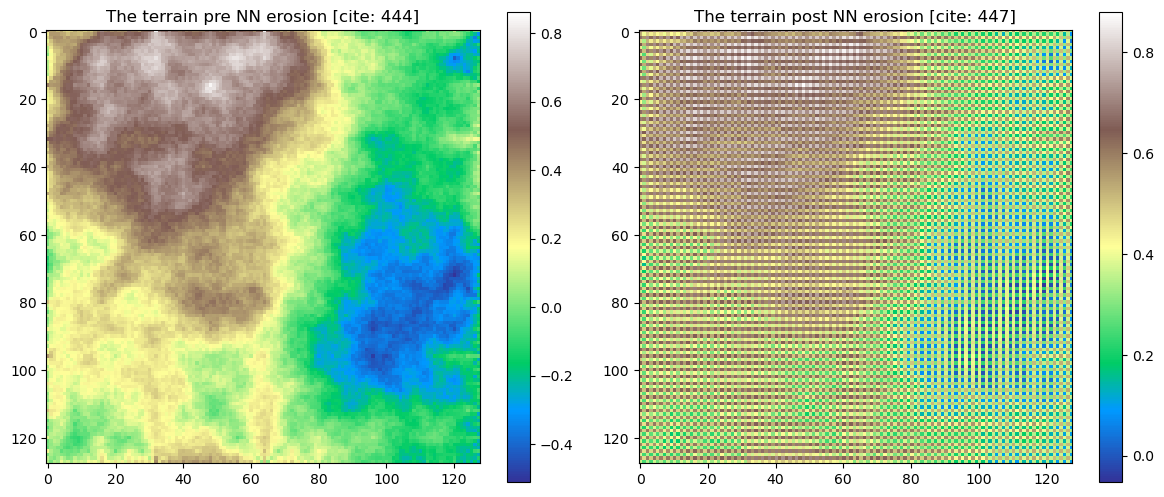

In [9]:
## NN erosion model

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the "Absolute Minimal" 2x2 Model [cite: 430]
class NNErosionModel(nn.Module):
    def __init__(self):
        super(NNErosionModel, self).__init__()
        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(4, 8),   # 4 input pixels (2x2) to 8 hidden nodes 
            nn.ReLU(),
            nn.Linear(8, 4),   # Output 4 height offsets
            nn.Unflatten(1, (1, 2, 2))
        )

    def forward(self, x):
        return self.network(x)

# 2. Initialize Terrain and Model
size = 128  # Power of 2 for easy 2x2 patching
#terrain = torch.zeros((1, 1, size, size))
# Create a test feature: a central plateau [cite: 444]
#terrain[:, :, 40:88, 40:88] = 1.0 

model = NNErosionModel()
optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

# 3. Training on a simple Erosion/Deposition Pattern [cite: 429, 430]
# Pattern: High point (1.0) erodes, Low point (0.0) gains height
x_train = torch.tensor([[[[1.0, 0.8], [0.9, 0.7]]]]).float()
y_train = torch.tensor([[[[0.9, 0.8], [0.8, 0.7]]]]).float() # Mass redistribution

print("Training minimal setup...")
for epoch in range(500):
    optimizer.zero_grad()
    output = model(x_train)
    loss = criterion(output, y_train)
    loss.backward()
    optimizer.step()

# 4. Apply One-Pass Erosion [cite: 431]
model.eval()
model.eval()
model.eval()
post_erosion = terrain.clone()

with torch.no_grad():
    for y in range(0, size, 2):
        for x in range(0, size, 2):
            patch = terrain[:, :, y:y+2, x:x+2]
            prediction = model(patch)
            post_erosion[:, :, y:y+2, x:x+2] = prediction

# 5. Visualization (Matching Wiki Figures) [cite: 434, 443]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

im1 = ax1.imshow(terrain.squeeze().numpy(), cmap='terrain')
ax1.set_title("The terrain pre NN erosion [cite: 444]")
plt.colorbar(im1, ax=ax1)

im2 = ax2.imshow(post_erosion.squeeze().numpy(), cmap='terrain')
ax2.set_title("The terrain post NN erosion [cite: 447]")
plt.colorbar(im2, ax=ax2)

plt.tight_layout()
plt.show()




**An Iterative Multi-Scale Model for Rapid Fractal Terrain Erosion**

**Abstract**

Generating realistic synthetic landscapes requires balancing computational efficiency with geomorphological accuracy. Traditional droplet-based hydraulic erosion models often require extensive parameter tuning and significant processing time. This paper presents an analytical breakdown of an iterative erosion algorithm and an artistic rendering pipeline using Direction-of-Descend (DoD) strokes. By recursively subdividing the terrain and redistributing mass based on local height averages, the model produces visually convincing features at multiple scales with high computational performance.

---

**1. Introduction**

Fractal landscape generation provides a foundation for synthetic terrains but often lacks weathered characteristics. We propose a computationally efficient iterative model that achieves realism through hierarchical mass redistribution. This paper details the implementation of this algorithm and a stroke-based rendering method that utilizes a fast inverse square root for optimized lighting calculations.

---

**2. Related Work**

**2.1 Terrain Erosion Models**

The simulation of realistic landscapes has traditionally been dominated by hydraulic erosion models, which simulate the physical interaction between water and soil. These are commonly categorized into particle-based (droplet) models and grid-based shallow water equations.

Early droplet models simulate individual raindrops that excavate soil based on kinetic energy and deposit material as they lose velocity or hit depressions. While physically grounded, these models often suffer from high computational costs and require significant parameter tweaking to avoid artifacts.

Traditional models like RUSLE (Revised Universal Soil Loss Equation) remain widely used for land management due to their simplicity, but they are increasingly being replaced by Landform Evolution Models (LEMs) for long-term topographic research. Physics-based simulations use Computational Fluid Dynamics (CFD) and the Shallow Water Equations to model sediment transport.

Recent research has explored Convolutional Neural Networks (CNNs) and Graph Neural Networks (GNNs) to bypass iterative solvers. Our work builds upon iterative, patch-based redistribution methods, mirroring hierarchical subdivision techniques used in fractal terrain generation but applying them to the erosion phase. By using patch subdivision and redistributing mass based on local height averages, the model achieves multi-scale weathering features at a fraction of the computational cost of particle simulations.

**2.2 Non-Photorealistic Terrain Rendering**

The visual representation of terrain through non-photorealistic rendering (NPR) often employs hatches or strokes to convey topography. The "Direction-of-Descend" (DoD) method, popularized by Buchin et al., serves as the primary inspiration for our rendering pipeline. This technique relies on path-tracing along the steepest gradient of a height field.

To enhance the artistic quality of these strokes, our system incorporates stroke extrusion and procedural path perturbation based on interactive pen-and-ink illustration techniques developed by Salisbury et al. This involves extruding points along a normal vector adjusted by lighting values to create thickness and depth. Furthermore, to maintain real-time performance during the lighting and normalization stages, we employ the Fast Inverse Square Root algorithm—a bit-manipulation technique famously utilized in Quake III Arena—to rapidly approximate surface normals and light attenuation. This combination of classical geomorphological tracing and optimized computer graphics allows for the generation of expressive, shaded landscape illustrations directly from Digital Elevation Models (DEM).

---

**3. Terrain Initialization and Optimization**

The foundation is a fractal base created via random midpoint displacement. To optimize subsequent rendering calculations, the implementation utilizes a Fast Inverse Square Root (derived from the Quake III Arena algorithm) to normalize vectors:

$$y = \frac{1}{\sqrt{x}} \approx \text{0x5f3759df} - (\text{int\_bits} >> 1)$$

This is implemented via bit manipulation of floating-point exponents to provide a rapid first approximation followed by a single iteration of Newton's method.

---

**4. Iterative Erosion Methodology**

The iterative erosion process operates on a top-down hierarchical patch structure.

**4.1 Multi-Point Sampling and Extrema Identification**

For each $n \times n$ patch, the model identifies the "high" and "low" sub-patches by sampling 13 distinct points: the 4 corners, 4 mid-edges, 4 sub-patch centers, and the central midpoint. The average height ($h_{avg}$) for a sub-patch is calculated as:

$$h_{avg} = \frac{1}{5}\sum_{i=0}^{4} h_i$$

where $h_i$ represents the heights of the sub-patch's four corners and its center point.

**4.2 Mass Redistribution Logic**

Once the highest and lowest sub-patches are identified, soil is redistributed based on a scale-dependent "rain" factor:

- **Erosion Portion ($\Delta h_{ero}$)**: $\frac{n_{drops}}{n_{grid}^2}$, where $n_{drops}$ is the number of drops and $n_{grid}$ is the current grid size.
- **Deposition Portion ($\Delta h_{dep}$)**: $\frac{\Delta h_{ero}}{2}$.

**Height Adjustment**: The terrain at the high index is incremented by $\Delta h_{dep}$, while the low index is decremented by $\Delta h_{ero}$.

---

**5. Direction-of-Descend (DoD) Stroke Rendering**

To visualize the erosion, the model employs "Direction-of-Descend" strokes that follow the steepest gradient.

**5.1 Gradient Path Tracing**

Stroke paths are generated by calculating the gradient $\nabla h$ at seed points. The algorithm samples four neighbors and updates the stroke position $\vec{p}$ toward the maximum (uphill) or minimum (downhill) neighbor.

**5.2 Artistic Lighting and Projection**

The strokes are rendered using an isometric projection translated to screen coordinates:

- **Isometric Transform**: $x_{screen} = x - z$ and $y_{screen} = y - \frac{x + z}{2}$

- **Lighting Calculation**: Lighting intensity ($I$) is determined by the dot product of the light vector $\vec{L}$ and the surface gradient, normalized using the fast inverse square root:

$$I = \vec{L} \cdot \frac{\nabla h}{\|\nabla h\|}$$

Strokes are color-coded (e.g., orange for highlight, slate gray for shadow) based on whether $I$ exceeds a specified threshold.

---

**6. Experiments**

Results from 10.000 runs:

| Approach | Mean Time | Standard Deviation |
|----------|-----------|-------------------|
| Classic droplet-based | 7.275 ms | 1.044 ms |
| Iterative (proposed) | 2.956 ms | 0.2689 ms |

The iterative model demonstrates approximately **2.5× speedup** over traditional droplet-based approaches with significantly lower variance.

---

**7. Conclusion**

The iterative model replaces complex fluid dynamics with deterministic redistribution. By increasing erosion mass at smaller scales, the algorithm effectively removes grid artifacts while developing intricate drainage features. Coupled with the DoD stroke pipeline, this method provides a high-performance solution for generating and rendering weathered synthetic landscapes.

---

**References**

1. Buchin, K., Costa Sousa, M., Döllner, J., Samavati, F., & Walther, M. (2004). Illustrating Terrains using Direction of Slope and Lighting. *Eurographics/IEEE VGTC Symposium on Visualization*.
2. Salisbury, M. P., Anderson, S. E., Barzel, R., & Salesin, D. H. (1994). Interactive pen-and-ink illustration. *ACM SIGGRAPH*, 101–108.
3. Unilmalas. (n.d.). *Fractal Erosion Wiki*: Iterative Erosion Implementation and Stroke Rendering. [Wiki documentation]
4. Hertzmann, A. (2024). A Survey of Stroke-Based Rendering. [Updated for AI-integrated pipelines]


